# Study Analysis

The study follows five sequential analytical stages, progressing from the identification of genre-conditioned monetization–success relationships to their cross-market, temporal, gameplay, and national-context characterization.

---
### Stage 1 — Genre-Level Interaction Analysis

The **Interaction-Analysis Framework** is applied separately to Ads and IAP across **10 game genres** for:

- **Install success**
- **Rating success**

Additive and multiplicative interaction measures are used to identify how monetization–success relationships differ between each focal genre and the remaining genres.

**The resulting pooled interaction profiles provide the foundation for the subsequent cross-market and temporal analyses.**

### Stage 2 — Cross-Market Analysis

The genre-conditioned relationships identified in Stage 1 are re-estimated independently across **42 national Google Play markets**.

This stage evaluates:

- **Cross-market recurrence** of the interaction patterns
- **Variation in interaction magnitude** across national markets
- Consistency of the relationships for **install and rating success**

The resulting country-level profiles establish which relationships recur across national marketplace contexts.

### Stage 3 — Temporal Analysis

The cross-market relationships are evaluated across **14 monthly periods (January 2025–February 2026)** within national markets.

The analysis examines:

- Interaction patterns within **country–month contexts**
- Temporal consistency for **install and rating success**
- Whether recurring cross-market relationships remain **stable or change over time**

This provides the temporal assessment of the relationships established in the preceding stages.

### Stage 4 — Gameplay Characterization

Recurring positive and negative interaction profiles are connected to the gameplay characteristics of the games representing them.

The characterization focuses on:

- **Nine Ads and IAP × genre profiles**
- Systematically selected games representing each profile
- Gameplay characteristics derived from **store and gameplay information**

This stage provides a substantive interpretation of the forms and structures of play associated with the recurring statistical relationships.

### Stage 5 — National-Context Analysis

The final stage examines whether variation in the magnitude of recurring interactions across markets corresponds with **national context**.

Country-specific interaction magnitudes are examined in relation to:

- **Demographic characteristics**
- **Socioeconomic characteristics**
- **Digital-context characteristics**

This stage separates the **recurrence of the relationships across markets** from variation in their **magnitude across national contexts**.

> Detailed statistical procedures, classification criteria, analytical samples, and outputs are presented within the corresponding stage sections below.

## ****************************************************************************************************

## Dataset

The study uses a country–month panel of free-to-play Android games across 42 national Google Play markets and 14 monthly periods (January 2025–February 2026). Each observation represents a game–market–month record and includes game identity, genre, monetization features (Ads and IAP), marketplace outcomes (installs and average rating), and the corresponding binary success measures.

In [1]:
import pandas as pd
import numpy as np

# Load dataset
apps = pd.read_csv("ads_iap_googlePlayStore_42country_month_panel.csv")

# Dataset overview
print("Rows:", len(apps))
print("Columns:", len(apps.columns))
print("Unique apps:", apps["game_id"].nunique())
print("Unique genres:", apps["genre"].nunique())
print("Unique countries:", apps["country"].nunique())
print("Unique months:", apps["month"].nunique())

# Column names
print("\nColumns:")
print(apps.columns.tolist())

Rows: 1778700
Columns: 11
Unique apps: 3025
Unique genres: 10
Unique countries: 42
Unique months: 14

Columns:
['game_id', 'game_title', 'country', 'month', 'genre', 'contains_ads', 'offers_iap', 'installs', 'average_rating', 'install_success', 'rating_success']


## ****************************************************************************************************

# Interaction-Analysis Framework

This section defines the statistical framework used to estimate and classify monetization × genre interactions throughout the empirical analysis.

The framework consists of seven steps:

1. Construct 2×2 contingency tables
2. Estimate conditional success probabilities
3. Assess differences in proportions (Δp)
4. Estimate conditional odds ratios (OR)
5. Evaluate additive interaction using DDP
6. Evaluate multiplicative interaction using RoR
7. Classify interaction patterns using 95% confidence intervals

The framework is defined once and subsequently applied to different analytical contexts in Stages 1–3.

In [5]:
# ================================================================
# 0. ANALYSIS SETUP
# ================================================================

# Work on a copy of the prepared application-level dataset.
df = apps.copy()

# Two-sided 95% confidence interval multiplier.
Z = 1.96

# Monetization variables examined as feature r in the framework.
exposure_map = {
    "contains_ads": "Ads",
    "offers_iap": "IAP"
}

# Possible joint classifications across the additive and
# multiplicative interaction scales.
JOINT_PATTERNS = [
    "++",   # positive on both scales
    "--",   # negative on both scales
    "00",   # neither scale establishes interaction
    "+0",   # positive additive interaction only
    "0+",   # positive multiplicative interaction only
    "-0",   # negative additive interaction only
    "0-",   # negative multiplicative interaction only
    "+-",   # additive positive, multiplicative negative
    "-+"    # additive negative, multiplicative positive
]


# ================================================================
# 1. STATISTICAL SUPPORT FUNCTIONS
# ================================================================
#
# These functions implement the standard errors and computational
# safeguards used by Steps 3–6 of the seven-step framework.
# ================================================================

def safe_div(a, b):
    """Return a/b, or NaN when the denominator is zero."""
    return np.nan if b == 0 else a / b


def se_prob_diff(p1, n1, p2, n2):
    """
    Standard error of a difference in estimated success probabilities.

    Used in Framework Step 3 to quantify uncertainty around the
    within-stratum probability difference.
    """
    if n1 == 0 or n2 == 0:
        return np.nan

    return np.sqrt(
        (p1 * (1 - p1)) / n1 +
        (p2 * (1 - p2)) / n2
    )


def se_log_or(a, b, c, d):
    """
    Standard error of a log odds ratio.

    Used in Framework Step 4. Counts supplied to this function are
    Haldane-Anscombe corrected when a zero cell is present.
    """
    if 0 in (a, b, c, d):
        return np.nan

    return np.sqrt(
        1 / a + 1 / b + 1 / c + 1 / d
    )


def se_ddp(se1, se2):
    """
    Standard error of the difference of probability differences (DDP).

    Used in Framework Step 5.
    """
    if pd.isna(se1) or pd.isna(se2):
        return np.nan

    return np.sqrt(se1**2 + se2**2)


def se_log_ror(se1, se2):
    """
    Standard error of log(RoR).

    Used in Framework Step 6.
    """
    if pd.isna(se1) or pd.isna(se2):
        return np.nan

    return np.sqrt(se1**2 + se2**2)


def apply_correction_if_needed(a, b, c, d, correction=0.5):
    """
    Apply a Haldane-Anscombe correction only when a 2×2 table
    contains a zero cell.

    When required, 0.5 is added to all four cells before estimating
    the odds ratio and its standard error. Otherwise, the observed
    counts are retained unchanged.
    """
    if 0 in (a, b, c, d):
        return (
            a + correction,
            b + correction,
            c + correction,
            d + correction,
            True
        )

    return a, b, c, d, False


# ================================================================
# 2. FRAMEWORK STEP 7: CI-BASED INTERACTION CLASSIFICATION
# ================================================================
#
# Steps 5 and 6 produce separate additive and multiplicative
# interaction estimates. These functions classify the evidence on
# each scale from its 95% CI.
#
# ================================================================

def classify_ddp(ddp, se):
    """
    Classify additive interaction from the 95% CI for DDP.

    + : CI lies entirely above 0
    - : CI lies entirely below 0
    0 : CI includes 0
    """
    if pd.isna(ddp) or pd.isna(se):
        return "NA"

    lo = ddp - Z * se
    hi = ddp + Z * se

    if lo > 0:
        return "+"
    elif hi < 0:
        return "-"
    else:
        return "0"


def classify_ror(log_ror, se_log):
    """
    Classify multiplicative interaction from the 95% CI for log(RoR).

    + : CI lies entirely above 0, equivalent to RoR CI > 1
    - : CI lies entirely below 0, equivalent to RoR CI < 1
    0 : CI includes 0, equivalent to RoR CI including 1
    """
    if pd.isna(log_ror) or pd.isna(se_log):
        return "NA"

    lo = log_ror - Z * se_log
    hi = log_ror + Z * se_log

    if lo > 0:
        return "+"
    elif hi < 0:
        return "-"
    else:
        return "0"


def combined_direction(ddp_dir, ror_dir):
    """
    Preserve the joint interaction pattern across both scales.

    The first symbol refers to additive interaction (DDP).
    The second symbol refers to multiplicative interaction (RoR).

        ++ : positive on both scales
        -- : negative on both scales
        00 : neither scale establishes interaction

        +0 : positive additive interaction only
        0+ : positive multiplicative interaction only
        -0 : negative additive interaction only
        0- : negative multiplicative interaction only

        +- : positive additive / negative multiplicative
        -+ : negative additive / positive multiplicative

    Thus, lack of statistical support on both scales (00), evidence
    on only one scale, and disagreement between scales remain
    analytically distinct.
    """
    if "NA" in (ddp_dir, ror_dir):
        return "NA"

    return ddp_dir + ror_dir


# ================================================================
# 3. SEVEN-STEP INTERACTION-ANALYSIS FRAMEWORK
# ================================================================

def interaction_stats(data, exposure, genre, outcome, correction=0.5):
    """
    Apply the seven-step Interaction-Analysis Framework described
    in the Method section.

    Parameters
    ----------
    data : pandas.DataFrame
        Dataset on which the interaction is estimated.

    exposure : str
        Binary feature r. In the empirical application this is
        either advertisement presence or IAP availability.

    genre : str
        Context feature c. Observations belonging to the specified
        genre form stratum c; all remaining genres form stratum c-bar.

    outcome : str
        Binary success outcome y (install_success or rating_success).

    correction : float, default=0.5
        Haldane-Anscombe correction used for odds-ratio estimation
        when a contingency-table cell equals zero.

    Returns
    -------
    dict
        Stratum-specific probability differences, DDP, conditional
        odds-ratio interaction (RoR), standard errors, and separate
        and joint CI-based interaction classifications.
    """

    d = data.copy()

    # Map the empirical variables onto the general framework notation:
    #
    # r = monetization feature (Ads or IAP)
    # c = focal genre
    # y = marketplace-success outcome
    #
    # c-bar therefore consists of all observations outside the
    # focal genre.

    d["stratum"] = np.where(
        d["genre"] == genre,
        genre,
        f"Non-{genre}"
    )

    d["r"] = d[exposure].astype(int)
    d["y"] = d[outcome].astype(int)


    # ------------------------------------------------------------
    # FRAMEWORK STEP 1:
    # Construct 2×2 contingency tables
    # ------------------------------------------------------------
    #
    # Within strata c and c-bar, cross-classify:
    #
    #               r = 1       r = 0
    # y = 1           a           c
    # y = 0           b           d
    #
    # These observed frequencies provide the empirical basis for
    # all subsequent calculations.

    def get_counts(sub):
        a = int(((sub["y"] == 1) & (sub["r"] == 1)).sum())
        b = int(((sub["y"] == 0) & (sub["r"] == 1)).sum())
        c = int(((sub["y"] == 1) & (sub["r"] == 0)).sum())
        d0 = int(((sub["y"] == 0) & (sub["r"] == 0)).sum())

        return a, b, c, d0

    stratum_c = d[d["stratum"] == genre]
    stratum_not_c = d[d["stratum"] != genre]

    # Counts for focal genre c
    a, b, c, d0 = get_counts(stratum_c)

    # Counts for all non-focal genres c-bar
    e, f, h, i = get_counts(stratum_not_c)

    n_rc = a + b
    n_not_r_c = c + d0

    n_r_not_c = e + f
    n_not_r_not_c = h + i


    # ------------------------------------------------------------
    # FRAMEWORK STEP 2:
    # Estimate conditional success probabilities
    # ------------------------------------------------------------
    #
    # Estimate P(y | r,c), P(y | r-bar,c),
    # P(y | r,c-bar), and P(y | r-bar,c-bar).

    p_exp_c = safe_div(a, n_rc)
    p_no_c = safe_div(c, n_not_r_c)

    p_exp_not_c = safe_div(e, n_r_not_c)
    p_no_not_c = safe_div(h, n_not_r_not_c)


    # ------------------------------------------------------------
    # FRAMEWORK STEP 3:
    # Assess within-stratum differences in proportions
    # ------------------------------------------------------------
    #
    # Δp_r|c     = P(y | r,c)     - P(y | r-bar,c)
    # Δp_r|c-bar = P(y | r,c-bar) - P(y | r-bar,c-bar)

    dp_c = p_exp_c - p_no_c
    dp_not_c = p_exp_not_c - p_no_not_c

    se_dp_c = se_prob_diff(
        p_exp_c, n_rc,
        p_no_c, n_not_r_c
    )

    se_dp_not_c = se_prob_diff(
        p_exp_not_c, n_r_not_c,
        p_no_not_c, n_not_r_not_c
    )


    # ------------------------------------------------------------
    # FRAMEWORK STEP 4:
    # Estimate conditional odds ratios
    # ------------------------------------------------------------
    #
    # Estimate the association between r and y separately within
    # strata c and c-bar.
    #
    # A Haldane-Anscombe correction is applied only when a zero
    # cell would otherwise make the odds ratio undefined.

    a2, b2, c2, d2, corrected_c = apply_correction_if_needed(
        a, b, c, d0, correction
    )

    e2, f2, h2, i2, corrected_not_c = apply_correction_if_needed(
        e, f, h, i, correction
    )

    or_c = safe_div(
        a2 * d2,
        b2 * c2
    )

    or_not_c = safe_div(
        e2 * i2,
        f2 * h2
    )

    se_log_or_c = (
        se_log_or(a2, b2, c2, d2)
        if corrected_c
        else se_log_or(a, b, c, d0)
    )

    se_log_or_not_c = (
        se_log_or(e2, f2, h2, i2)
        if corrected_not_c
        else se_log_or(e, f, h, i)
    )


    # ------------------------------------------------------------
    # FRAMEWORK STEP 5:
    # Evaluate additive interaction (DDP)
    # ------------------------------------------------------------
    #
    # DDP = Δp_r|c - Δp_r|c-bar
    #
    # The null value is DDP = 0.

    ddp = dp_c - dp_not_c

    se_ddp_val = se_ddp(
        se_dp_c,
        se_dp_not_c
    )

    ddp_ci_low = (
        ddp - Z * se_ddp_val
        if pd.notna(se_ddp_val)
        else np.nan
    )

    ddp_ci_high = (
        ddp + Z * se_ddp_val
        if pd.notna(se_ddp_val)
        else np.nan
    )

    ddp_direction = classify_ddp(
        ddp,
        se_ddp_val
    )


    # ------------------------------------------------------------
    # FRAMEWORK STEP 6:
    # Evaluate multiplicative interaction (RoR)
    # ------------------------------------------------------------
    #
    # RoR = OR_r|c / OR_r|c-bar
    #
    # Inference is performed on log(RoR), whose null value is 0
    # (equivalent to RoR = 1).

    ror = safe_div(
        or_c,
        or_not_c
    )

    log_ror = (
        np.log(ror)
        if pd.notna(ror) and ror > 0
        else np.nan
    )

    se_log_ror_val = se_log_ror(
        se_log_or_c,
        se_log_or_not_c
    )

    log_ror_ci_low = (
        log_ror - Z * se_log_ror_val
        if pd.notna(log_ror) and pd.notna(se_log_ror_val)
        else np.nan
    )

    log_ror_ci_high = (
        log_ror + Z * se_log_ror_val
        if pd.notna(log_ror) and pd.notna(se_log_ror_val)
        else np.nan
    )

    # Exponentiated CI is retained for transparent reporting.
    ror_ci_low = (
        np.exp(log_ror_ci_low)
        if pd.notna(log_ror_ci_low)
        else np.nan
    )

    ror_ci_high = (
        np.exp(log_ror_ci_high)
        if pd.notna(log_ror_ci_high)
        else np.nan
    )

    ror_direction = classify_ror(
        log_ror,
        se_log_ror_val
    )


    # ------------------------------------------------------------
    # FRAMEWORK STEP 7:
    # Interpret the interaction pattern
    # ------------------------------------------------------------
    #
    # The additive and multiplicative classifications are retained
    # separately and then combined without discarding information.
    #
    # Examples:
    # ++ = statistically supported positive interaction on both scales
    # -- = statistically supported negative interaction on both scales
    # 00 = neither scale establishes departure from its null
    # +0 = positive additive interaction only
    # 0+ = positive multiplicative interaction only
    # +- / -+ = statistically supported directions differ by scale

    joint_direction = combined_direction(
        ddp_direction,
        ror_direction
    )


    return {
        # Additive interaction
        "DDP": ddp,
        "SE_DDP": se_ddp_val,
        "DDP_CI_low": ddp_ci_low,
        "DDP_CI_high": ddp_ci_high,
        "ddp_direction": ddp_direction,

        # Multiplicative interaction
        "RoR": ror,
        "log_RoR": log_ror,
        "SE_log_RoR": se_log_ror_val,
        "RoR_CI_low": ror_ci_low,
        "RoR_CI_high": ror_ci_high,
        "ror_direction": ror_direction,

        # Joint Step-7 interpretation
        "direction": joint_direction,

        # Stratum-specific associations
        "dp_genre": dp_c,
        "dp_rest": dp_not_c,
        "or_genre": or_c,
        "or_rest": or_not_c,

        # Conditional probabilities
        "p_exp_genre": p_exp_c,
        "p_no_genre": p_no_c,
        "p_exp_rest": p_exp_not_c,
        "p_no_rest": p_no_not_c,

        # Sample sizes
        "n_genre": n_rc + n_not_r_c,
        "n_rest": n_r_not_c + n_not_r_not_c,

        # Zero-cell correction indicators
        "corrected_genre": corrected_c,
        "corrected_rest": corrected_not_c,
    }

## ****************************************************************************************************

# Stage 1 — Genre-Level Interaction Analysis

The **Interaction-Analysis Framework** is first applied to the complete pooled dataset, without stratification by country or month.

For each **Ads/IAP × genre** combination, interactions are estimated separately for:

- **Install success**
- **Rating success**

Each focal genre is compared with all remaining genres.

The resulting pooled estimates establish the genre-conditioned monetization–success relationships that are subsequently examined across national markets and temporal contexts.

In [6]:
# ================================================================
# EMPIRICAL STAGE 1:
# POOLED MONETIZATION × GENRE INTERACTION ANALYSIS
# ================================================================
#
# The seven-step framework is first applied to the full dataset.
#
# For each Ads/IAP × genre combination, interactions are estimated
# for both marketplace-success outcomes:
#
#   1. install success
#   2. rating success
#
# These estimates describe the pooled interaction pattern before
# examining whether that pattern varies across country or time.
# ================================================================

def make_pooled_summary(data):
    """Estimate pooled interactions across the complete dataset."""

    rows = []

    for exposure, label in exposure_map.items():

        for genre in sorted(data["genre"].unique()):

            install = interaction_stats(
                data,
                exposure,
                genre,
                "install_success"
            )

            rating = interaction_stats(
                data,
                exposure,
                genre,
                "rating_success"
            )

            rows.append({
                "Monetization": label,
                "Genre": genre,

                "Install DDP": install["DDP"],
                "Install DDP 95% CI Low": install["DDP_CI_low"],
                "Install DDP 95% CI High": install["DDP_CI_high"],
                "Install RoR": install["RoR"],
                "Install RoR 95% CI Low": install["RoR_CI_low"],
                "Install RoR 95% CI High": install["RoR_CI_high"],
                "Install DDP Direction": install["ddp_direction"],
                "Install RoR Direction": install["ror_direction"],
                "Install Joint Pattern": install["direction"],

                "Rating DDP": rating["DDP"],
                "Rating DDP 95% CI Low": rating["DDP_CI_low"],
                "Rating DDP 95% CI High": rating["DDP_CI_high"],
                "Rating RoR": rating["RoR"],
                "Rating RoR 95% CI Low": rating["RoR_CI_low"],
                "Rating RoR 95% CI High": rating["RoR_CI_high"],
                "Rating DDP Direction": rating["ddp_direction"],
                "Rating RoR Direction": rating["ror_direction"],
                "Rating Joint Pattern": rating["direction"],
            })

    out = pd.DataFrame(rows)

    out["sort"] = out["Monetization"].map({
        "Ads": 0,
        "IAP": 1
    })

    out = out.sort_values(
        ["sort", "Install DDP"],
        ascending=[True, False]
    )

    return out.drop(columns="sort")


pooled_summary = make_pooled_summary(df)

print("\nEMPIRICAL STAGE 1: POOLED INTERACTION ANALYSIS")
display(pooled_summary.round(3))


EMPIRICAL STAGE 1: POOLED INTERACTION ANALYSIS


,Monetization,Genre,Install DDP,Install DDP 95% CI Low,Install DDP 95% CI High,Install RoR,Install RoR 95% CI Low,Install RoR 95% CI High,Install DDP Direction,Install RoR Direction,Install Joint Pattern,Rating DDP,Rating DDP 95% CI Low,Rating DDP 95% CI High,Rating RoR,Rating RoR 95% CI Low,Rating RoR 95% CI High,Rating DDP Direction,Rating RoR Direction,Rating Joint Pattern
4,Ads,Puzzle,0.349,0.345,0.352,5.019,4.941,5.097,+,+,++,0.116,0.113,0.120,1.597,1.573,1.620,+,+,++
2,Ads,Casual,0.262,0.255,0.269,4.444,4.304,4.588,+,+,++,0.110,0.103,0.116,1.555,1.511,1.600,+,+,++
1,Ads,Arcade,0.047,0.040,0.053,1.210,1.178,1.242,+,+,++,0.016,0.010,0.023,1.067,1.039,1.095,+,+,++
3,Ads,Educational,-0.082,-0.086,-0.077,0.650,0.630,0.671,-,-,--,-0.025,-0.030,-0.019,0.887,0.866,0.909,-,-,--
8,Ads,Sports,-0.084,-0.089,-0.079,0.692,0.675,0.709,-,-,--,-0.023,-0.028,-0.017,0.906,0.886,0.927,-,-,--
6,Ads,Racing,-0.094,-0.100,-0.087,0.636,0.614,0.659,-,-,--,-0.024,-0.031,-0.017,0.897,0.871,0.924,-,-,--
0,Ads,Action,-0.235,-0.239,-0.231,0.369,0.363,0.376,-,-,--,-0.061,-0.065,-0.057,0.781,0.769,0.794,-,-,--
7,Ads,Simulation,-0.281,-0.286,-0.277,0.288,0.282,0.295,-,-,--,-0.088,-0.092,-0.083,0.701,0.687,0.715,-,-,--
9,Ads,Strategy,-0.363,-0.369,-0.357,0.225,0.219,0.231,-,-,--,-0.106,-0.112,-0.100,0.645,0.629,0.661,-,-,--
5,Ads,RPG,-0.441,-0.447,-0.436,0.160,0.156,0.164,-,-,--,-0.135,-0.141,-0.130,0.568,0.555,0.581,-,-,--


## ****************************************************************************************************

# Stage 2 — Cross-Market Analysis

The second stage evaluates whether the genre-conditioned monetization–success relationships identified in Stage 1 recur across national markets.

The **Interaction-Analysis Framework** is re-applied independently within each of the **42 national Google Play markets**. For each Ads/IAP × genre combination, additive interaction (DDP) and multiplicative interaction (RoR) are estimated separately for **install success** and **rating success**, together with their 95% confidence intervals.

For each success measure, country-level evidence is classified according to the joint additive and multiplicative interaction pattern:

- **Positive (+):** positive interaction on both scales (`++`)
- **Negative (−):** negative interaction on both scales (`--`)
- **Null (0):** neither scale establishes interaction (`00`)
- **Mixed (M):** scale-specific or directionally inconsistent evidence (`+0`, `0+`, `-0`, `0-`, `+-`, `-+`)

The resulting country profiles identify which monetization–genre relationships recur across markets for each marketplace-success measure and quantify cross-market variation in their interaction magnitude.

In [8]:
# ================================================================
# EMPIRICAL STAGE 2:
# CROSS-MARKET MONETIZATION × GENRE INTERACTION ANALYSIS
# ================================================================
#
# The seven-step framework is repeated independently within each
# of the 42 national Google Play markets.
#
# For each Ads/IAP × genre combination, interactions are estimated
# separately within each country for both marketplace-success outcomes:
#
#   1. install success
#   2. rating success
#
# These estimates evaluate whether the pooled interaction patterns
# identified in Stage 1 recur across national marketplace contexts
# and quantify cross-market variation in interaction magnitude.
# ================================================================

def pair_by_country(data, exposure, genre, outcome):
    """
    Apply the complete seven-step interaction framework separately
    to each country for one monetization × genre × outcome combination.
    """

    rows = []

    for country in sorted(data["country"].dropna().unique()):

        sub = data[data["country"] == country]

        stats = interaction_stats(
            sub,
            exposure,
            genre,
            outcome
        )

        rows.append({
            "country": country,

            "DDP": stats["DDP"],
            "DDP_CI_low": stats["DDP_CI_low"],
            "DDP_CI_high": stats["DDP_CI_high"],
            "DDP_direction": stats["ddp_direction"],

            "RoR": stats["RoR"],
            "RoR_CI_low": stats["RoR_CI_low"],
            "RoR_CI_high": stats["RoR_CI_high"],
            "RoR_direction": stats["ror_direction"],

            "direction": stats["direction"],

            "dp_genre": stats["dp_genre"],
            "dp_rest": stats["dp_rest"],
        })

    return pd.DataFrame(rows)


def count_joint_patterns(temp, prefix):
    """
    Count all joint Step-7 interaction patterns.

    This prevents single-scale effects or cross-scale disagreement
    from being incorrectly collapsed into the 00 category.
    """

    counts = {}

    for pattern in JOINT_PATTERNS:
        counts[f"{prefix} {pattern}"] = (
            temp["direction"] == pattern
        ).sum()

    counts[f"{prefix} NA"] = (
        temp["direction"] == "NA"
    ).sum()

    return counts


def make_country_summary(data, outcome):
    """
    Summarise the distribution of CI-supported interaction patterns
    across countries for each monetization × genre combination for
    one marketplace-success outcome.
    """

    rows = []

    for exposure, label in exposure_map.items():

        for genre in sorted(data["genre"].dropna().unique()):

            temp = pair_by_country(
                data,
                exposure,
                genre,
                outcome
            )

            rows.append({
                "Monetization": label,
                "Genre": genre,
                "Mean Country DDP": temp["DDP"].mean(),
                "Mean Country RoR": temp["RoR"].mean(),

                **count_joint_patterns(temp, "Country")
            })

    out = pd.DataFrame(rows)

    out["sort"] = out["Monetization"].map({
        "Ads": 0,
        "IAP": 1
    })

    out = out.sort_values(
        ["sort", "Mean Country DDP"],
        ascending=[True, False]
    )

    return out.drop(columns="sort")


# ================================================================
# INSTALL SUCCESS
# ================================================================

country_summary_install = make_country_summary(
    df,
    "install_success"
)

print("\nEMPIRICAL STAGE 2: CROSS-MARKET ANALYSIS — INSTALL SUCCESS")
display(country_summary_install.round(3))


# ================================================================
# RATING SUCCESS
# ================================================================

country_summary_rating = make_country_summary(
    df,
    "rating_success"
)

print("\nEMPIRICAL STAGE 2: CROSS-MARKET ANALYSIS — RATING SUCCESS")
display(country_summary_rating.round(3))


EMPIRICAL STAGE 2: CROSS-MARKET ANALYSIS — INSTALL SUCCESS


,Monetization,Genre,Mean Country DDP,Mean Country RoR,Country ++,Country --,Country 00,Country +0,Country 0+,Country -0,Country 0-,Country +-,Country -+,Country NA
4,Ads,Puzzle,0.341,5.181,42,0,0,0,0,0,0,0,0,0
2,Ads,Casual,0.255,4.851,42,0,0,0,0,0,0,0,0,0
1,Ads,Arcade,0.042,1.197,19,0,23,0,0,0,0,0,0,0
3,Ads,Educational,-0.083,0.657,0,39,2,0,0,1,0,0,0,0
6,Ads,Racing,-0.094,0.642,0,40,1,0,0,1,0,0,0,0
8,Ads,Sports,-0.097,0.653,0,42,0,0,0,0,0,0,0,0
0,Ads,Action,-0.236,0.371,0,42,0,0,0,0,0,0,0,0
7,Ads,Simulation,-0.274,0.300,0,42,0,0,0,0,0,0,0,0
9,Ads,Strategy,-0.350,0.231,0,42,0,0,0,0,0,0,0,0
5,Ads,RPG,-0.421,0.163,0,42,0,0,0,0,0,0,0,0



EMPIRICAL STAGE 2: CROSS-MARKET ANALYSIS — RATING SUCCESS


,Monetization,Genre,Mean Country DDP,Mean Country RoR,Country ++,Country --,Country 00,Country +0,Country 0+,Country -0,Country 0-,Country +-,Country -+,Country NA
4,Ads,Puzzle,0.114,1.583,42,0,0,0,0,0,0,0,0,0
2,Ads,Casual,0.107,1.546,42,0,0,0,0,0,0,0,0,0
1,Ads,Arcade,0.015,1.069,5,0,37,0,0,0,0,0,0,0
6,Ads,Racing,-0.024,0.899,0,7,35,0,0,0,0,0,0,0
3,Ads,Educational,-0.025,0.887,0,13,26,0,0,0,3,0,0,0
8,Ads,Sports,-0.027,0.893,0,15,27,0,0,0,0,0,0,0
0,Ads,Action,-0.061,0.783,0,42,0,0,0,0,0,0,0,0
7,Ads,Simulation,-0.084,0.714,0,42,0,0,0,0,0,0,0,0
9,Ads,Strategy,-0.101,0.661,0,42,0,0,0,0,0,0,0,0
5,Ads,RPG,-0.127,0.587,0,42,0,0,0,0,0,0,0,0


## ****************************************************************************************************

# Stage 3 — Temporal Analysis

The third stage evaluates the temporal stability of the monetization × genre interaction patterns across the **14 monthly periods from January 2025 to February 2026**.

The **Interaction-Analysis Framework** is re-applied separately within each **country–month context**. For each Ads/IAP × genre combination, additive interaction (DDP) and multiplicative interaction (RoR) are estimated independently for **install success** and **rating success**.

Country–month interaction evidence is classified using the same joint 95% confidence-interval criteria applied in the preceding stages:

- **Positive (+):** positive interaction on both scales (`++`)
- **Negative (−):** negative interaction on both scales (`--`)
- **Null (0):** neither scale establishes interaction (`00`)
- **Mixed (M):** scale-specific or directionally inconsistent evidence (`+0`, `0+`, `-0`, `0-`, `+-`, `-+`)

This stage evaluates whether the cross-market interaction patterns identified in Stage 2 remain stable across observation periods within national markets.

In [9]:
# ================================================================
# EMPIRICAL STAGE 3:
# TEMPORAL MONETIZATION × GENRE INTERACTION ANALYSIS
# ================================================================
#
# The seven-step framework is repeated independently within each
# country–month context across the 42 national markets and
# 14 monthly observation periods.
#
# For each Ads/IAP × genre combination, interactions are estimated
# separately within each country–month context for both
# marketplace-success outcomes:
#
#   1. install success
#   2. rating success
#
# These estimates evaluate whether the cross-market interaction
# patterns identified in Stage 2 remain stable across observation
# periods within national marketplace contexts.
# ================================================================


def pair_by_country_month(data, exposure, genre, outcome):
    """
    Apply the complete seven-step Interaction-Analysis Framework
    separately within each country–month context for one
    monetization × genre × outcome combination.
    """

    rows = []

    contexts = (
        data[["country", "month"]]
        .drop_duplicates()
        .sort_values(["country", "month"])
    )

    for _, context in contexts.iterrows():

        country = context["country"]
        month = context["month"]

        sub = data[
            (data["country"] == country) &
            (data["month"] == month)
        ]

        stats = interaction_stats(
            sub,
            exposure,
            genre,
            outcome
        )

        rows.append({
            "country": country,
            "month": month,

            "DDP": stats["DDP"],
            "DDP_CI_low": stats["DDP_CI_low"],
            "DDP_CI_high": stats["DDP_CI_high"],
            "DDP_direction": stats["ddp_direction"],

            "RoR": stats["RoR"],
            "RoR_CI_low": stats["RoR_CI_low"],
            "RoR_CI_high": stats["RoR_CI_high"],
            "RoR_direction": stats["ror_direction"],

            "direction": stats["direction"],

            "dp_genre": stats["dp_genre"],
            "dp_rest": stats["dp_rest"],
        })

    return pd.DataFrame(rows)


def make_temporal_summary(data, outcome):
    """
    Summarise the distribution of CI-supported interaction patterns
    across country–month contexts for each monetization × genre
    combination and one marketplace-success outcome.
    """

    rows = []

    for exposure, label in exposure_map.items():

        for genre in sorted(data["genre"].dropna().unique()):

            temp = pair_by_country_month(
                data,
                exposure,
                genre,
                outcome
            )

            rows.append({
                "Monetization": label,
                "Genre": genre,
                "Mean Country-Month DDP": temp["DDP"].mean(),
                "Mean Country-Month RoR": temp["RoR"].mean(),

                **count_joint_patterns(
                    temp,
                    "Country-Month"
                )
            })

    out = pd.DataFrame(rows)

    out["sort"] = out["Monetization"].map({
        "Ads": 0,
        "IAP": 1
    })

    out = out.sort_values(
        ["sort", "Mean Country-Month DDP"],
        ascending=[True, False]
    )

    return out.drop(columns="sort")


# ================================================================
# INSTALL SUCCESS
# ================================================================

temporal_summary_install = make_temporal_summary(
    df,
    "install_success"
)

print(
    "\nEMPIRICAL STAGE 3: TEMPORAL ANALYSIS — INSTALL SUCCESS"
)
display(temporal_summary_install.round(3))


# ================================================================
# RATING SUCCESS
# ================================================================

temporal_summary_rating = make_temporal_summary(
    df,
    "rating_success"
)

print(
    "\nEMPIRICAL STAGE 3: TEMPORAL ANALYSIS — RATING SUCCESS"
)
display(temporal_summary_rating.round(3))


EMPIRICAL STAGE 3: TEMPORAL ANALYSIS — INSTALL SUCCESS


,Monetization,Genre,Mean Country-Month DDP,Mean Country-Month RoR,Country-Month ++,Country-Month --,Country-Month 00,Country-Month +0,Country-Month 0+,Country-Month -0,Country-Month 0-,Country-Month +-,Country-Month -+,Country-Month NA
4,Ads,Puzzle,0.342,5.321,588,0,0,0,0,0,0,0,0,0
2,Ads,Casual,0.255,5.460,512,0,35,0,41,0,0,0,0,0
1,Ads,Arcade,0.043,1.276,56,4,523,4,1,0,0,0,0,0
3,Ads,Educational,-0.083,0.710,1,118,383,0,0,86,0,0,0,0
6,Ads,Racing,-0.094,0.720,1,116,443,0,0,28,0,0,0,0
8,Ads,Sports,-0.098,0.682,1,197,365,0,0,24,1,0,0,0
0,Ads,Action,-0.236,0.379,0,582,5,0,0,1,0,0,0,0
7,Ads,Simulation,-0.275,0.307,0,586,2,0,0,0,0,0,0,0
9,Ads,Strategy,-0.351,0.240,0,582,6,0,0,0,0,0,0,0
5,Ads,RPG,-0.422,0.168,0,588,0,0,0,0,0,0,0,0



EMPIRICAL STAGE 3: TEMPORAL ANALYSIS — RATING SUCCESS


,Monetization,Genre,Mean Country-Month DDP,Mean Country-Month RoR,Country-Month ++,Country-Month --,Country-Month 00,Country-Month +0,Country-Month 0+,Country-Month -0,Country-Month 0-,Country-Month +-,Country-Month -+,Country-Month NA
4,Ads,Puzzle,0.114,1.611,405,0,175,8,0,0,0,0,0,0
2,Ads,Casual,0.107,1.642,142,0,445,1,0,0,0,0,0,0
1,Ads,Arcade,0.015,1.120,27,6,555,0,0,0,0,0,0,0
6,Ads,Racing,-0.025,0.955,5,26,554,2,0,1,0,0,0,0
3,Ads,Educational,-0.025,0.920,3,32,550,2,0,0,1,0,0,0
8,Ads,Sports,-0.027,0.927,8,38,539,0,0,1,2,0,0,0
0,Ads,Action,-0.061,0.797,1,138,447,0,0,2,0,0,0,0
7,Ads,Simulation,-0.084,0.732,0,179,408,0,0,1,0,0,0,0
9,Ads,Strategy,-0.101,0.684,1,140,443,0,0,4,0,0,0,0
5,Ads,RPG,-0.127,0.611,0,291,292,0,0,3,2,0,0,0


## ****************************************************************************************************

In [13]:
# ================================================================
# STANDALONE CONSOLIDATED SUMMARY
# POOLED, CROSS-MARKET, AND TEMPORAL INTERACTION RESULTS
# ================================================================
#
# This code independently generates a consolidated summary of:
#
#   Stage 1 — pooled interaction patterns
#   Stage 2 — recurrence across 42 countries
#   Stage 3 — recurrence across country–month contexts
#
# Results are calculated separately for:
#
#   1. install success
#   2. rating success
#
# Context-specific interaction patterns are summarized as:
#
#   + = both interaction scales significantly positive (++)
#   - = both interaction scales significantly negative (--)
#   0 = neither interaction scale significant (00)
#   M = scale-specific or directionally inconsistent evidence
#
# Requires:
#   apps
#   interaction_stats()
# ================================================================


import pandas as pd


# ------------------------------------------------------------
# ANALYSIS SETTINGS
# ------------------------------------------------------------

exposures = {
    "contains_ads": "Ads",
    "offers_iap": "IAP"
}

genres = sorted(apps["genre"].dropna().unique())

outcomes = {
    "install_success": "Install",
    "rating_success": "Rating"
}

mixed_patterns = {
    "+0", "0+",
    "-0", "0-",
    "+-", "-+"
}


# ------------------------------------------------------------
# COMPACT CLASSIFICATION
# ------------------------------------------------------------

def compact_class(direction):

    if direction == "++":
        return "+"

    if direction == "--":
        return "-"

    if direction == "00":
        return "0"

    if direction in mixed_patterns:
        return "M"

    return "NA"


# ------------------------------------------------------------
# FORMAT COUNTS AS + / 0 / - / M
# ------------------------------------------------------------

def format_counts(classifications):

    counts = classifications.value_counts()

    return (
        f"{counts.get('+', 0)}/"
        f"{counts.get('0', 0)}/"
        f"{counts.get('-', 0)}/"
        f"{counts.get('M', 0)}"
    )


# ------------------------------------------------------------
# MAIN SUMMARY
# ------------------------------------------------------------

rows = []

for exposure, monetization in exposures.items():

    for genre in genres:

        row = {
            "Monetization": monetization,
            "Genre": genre
        }

        for outcome, outcome_label in outcomes.items():

            # ====================================================
            # STAGE 1 — POOLED
            # ====================================================

            pooled = interaction_stats(
                apps,
                exposure,
                genre,
                outcome
            )

            row[f"{outcome_label} DDP"] = pooled["DDP"]
            row[f"{outcome_label} RoR"] = pooled["RoR"]
            row[f"{outcome_label} Direction"] = pooled["direction"]


            # ====================================================
            # STAGE 2 — COUNTRIES
            # ====================================================

            country_classes = []

            for country, country_data in apps.groupby(
                "country",
                sort=True
            ):

                stats = interaction_stats(
                    country_data,
                    exposure,
                    genre,
                    outcome
                )

                country_classes.append(
                    compact_class(stats["direction"])
                )

            country_classes = pd.Series(country_classes)

            row[
                f"{outcome_label} Countries (+/0/-/M)"
            ] = format_counts(country_classes)


            # ====================================================
            # STAGE 3 — COUNTRY–MONTH CONTEXTS
            # ====================================================

            temporal_classes = []

            for (country, month), context_data in apps.groupby(
                ["country", "month"],
                sort=True
            ):

                stats = interaction_stats(
                    context_data,
                    exposure,
                    genre,
                    outcome
                )

                temporal_classes.append(
                    compact_class(stats["direction"])
                )

            temporal_classes = pd.Series(temporal_classes)

            row[
                f"{outcome_label} Country-Months (+/0/-/M)"
            ] = format_counts(temporal_classes)

        rows.append(row)


# ------------------------------------------------------------
# FINAL TABLE
# ------------------------------------------------------------

final_summary = pd.DataFrame(rows)


# Ads first, followed by IAP
final_summary["_order"] = final_summary["Monetization"].map({
    "Ads": 0,
    "IAP": 1
})

final_summary = (
    final_summary
    .sort_values(
        ["_order", "Install DDP"],
        ascending=[True, False]
    )
    .drop(columns="_order")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

print("=" * 80)
print("CONSOLIDATED INTERACTION SUMMARY — STAGES 1–3")
print("=" * 80)

print(
    "\nContext counts are reported as + / 0 / - / M "
    "(positive / null / negative / mixed).\n"
)

display(final_summary.round(3))

CONSOLIDATED INTERACTION SUMMARY — STAGES 1–3

Context counts are reported as + / 0 / - / M (positive / null / negative / mixed).



,Monetization,Genre,Install DDP,Install RoR,Install Direction,Install Countries (+/0/-/M),Install Country-Months (+/0/-/M),Rating DDP,Rating RoR,Rating Direction,Rating Countries (+/0/-/M),Rating Country-Months (+/0/-/M)
0,Ads,Puzzle,0.349,5.019,++,42/0/0/0,588/0/0/0,0.116,1.597,++,42/0/0/0,405/175/0/8
1,Ads,Casual,0.262,4.444,++,42/0/0/0,512/35/0/41,0.110,1.555,++,42/0/0/0,142/445/0/1
2,Ads,Arcade,0.047,1.210,++,19/23/0/0,56/523/4/5,0.016,1.067,++,5/37/0/0,27/555/6/0
3,Ads,Educational,-0.082,0.650,--,0/2/39/1,1/383/118/86,-0.025,0.887,--,0/26/13/3,3/550/32/3
4,Ads,Sports,-0.084,0.692,--,0/0/42/0,1/365/197/25,-0.023,0.906,--,0/27/15/0,8/539/38/3
5,Ads,Racing,-0.094,0.636,--,0/1/40/1,1/443/116/28,-0.024,0.897,--,0/35/7/0,5/554/26/3
6,Ads,Action,-0.235,0.369,--,0/0/42/0,0/5/582/1,-0.061,0.781,--,0/0/42/0,1/447/138/2
7,Ads,Simulation,-0.281,0.288,--,0/0/42/0,0/2/586/0,-0.088,0.701,--,0/0/42/0,0/408/179/1
8,Ads,Strategy,-0.363,0.225,--,0/0/42/0,0/6/582/0,-0.106,0.645,--,0/0/42/0,1/443/140/4
9,Ads,RPG,-0.441,0.160,--,0/0/42/0,0/0/588/0,-0.135,0.568,--,0/0/42/0,0/292/291/5


In [15]:
# ================================================================
# POOLED + 14-MONTH INTERACTION SUMMARY
# INSTALL AND RATING SUCCESS
# ================================================================
#
# This table combines:
#
#   - Overall pooled DDP and RoR
#   - Overall interaction direction
#   - Interaction recurrence across the 14 observation months
#
# Results are reported separately for:
#
#   1. install success
#   2. rating success
#
# Monthly classifications:
#
#   + = ++
#   - = --
#   0 = 00
#   M = +0, 0+, -0, 0-, +-, or -+
#
# Monthly counts are reported as + / 0 / - / M.
# ================================================================


import pandas as pd


# ------------------------------------------------------------
# COMPACT INTERACTION CLASSIFICATION
# ------------------------------------------------------------

def compact_pattern(direction):

    if direction == "++":
        return "+"

    if direction == "--":
        return "-"

    if direction == "00":
        return "0"

    return "M"


# ------------------------------------------------------------
# GENERATE SUMMARY FOR ONE OUTCOME
# ------------------------------------------------------------

def make_month_summary(data, outcome, outcome_label):

    rows = []

    exposure_map = {
        "contains_ads": "Ads",
        "offers_iap": "IAP"
    }

    for exposure, monetization in exposure_map.items():

        for genre in sorted(data["genre"].dropna().unique()):

            # ====================================================
            # OVERALL POOLED INTERACTION
            # ====================================================

            pooled = interaction_stats(
                data,
                exposure,
                genre,
                outcome
            )


            # ====================================================
            # 14 MONTHLY INTERACTIONS
            # ====================================================

            monthly_patterns = []

            for month, month_data in data.groupby("month"):

                stats = interaction_stats(
                    month_data,
                    exposure,
                    genre,
                    outcome
                )

                monthly_patterns.append(
                    compact_pattern(stats["direction"])
                )


            counts = pd.Series(
                monthly_patterns
            ).value_counts()


            # ====================================================
            # SUMMARY ROW
            # ====================================================

            rows.append({

                "Monetization": monetization,
                "Genre": genre,

                f"{outcome_label} DDP":
                    pooled["DDP"],

                f"{outcome_label} RoR":
                    pooled["RoR"],

                f"{outcome_label} Int.":
                    compact_pattern(
                        pooled["direction"]
                    ),

                f"{outcome_label} Months (+/0/-/M)":
                    (
                        f"{counts.get('+', 0)}/"
                        f"{counts.get('0', 0)}/"
                        f"{counts.get('-', 0)}/"
                        f"{counts.get('M', 0)}"
                    )
            })

    return pd.DataFrame(rows)


# ================================================================
# INSTALL SUCCESS
# ================================================================

install_month_summary = make_month_summary(
    apps,
    outcome="install_success",
    outcome_label="Install"
)


# ================================================================
# RATING SUCCESS
# ================================================================

rating_month_summary = make_month_summary(
    apps,
    outcome="rating_success",
    outcome_label="Rating"
)


# ================================================================
# COMBINE INSTALL AND RATING
# ================================================================

monthly_summary = install_month_summary.merge(
    rating_month_summary,
    on=["Monetization", "Genre"]
)


# ------------------------------------------------------------
# ORDER RESULTS
# ------------------------------------------------------------

monthly_summary["_order"] = (
    monthly_summary["Monetization"].map({
        "Ads": 0,
        "IAP": 1
    })
)

monthly_summary = (
    monthly_summary
    .sort_values(
        ["_order", "Install DDP"],
        ascending=[True, False]
    )
    .drop(columns="_order")
    .reset_index(drop=True)
)


# ================================================================
# DISPLAY
# ================================================================

print("=" * 80)
print("POOLED + 14-MONTH INTERACTION SUMMARY")
print("=" * 80)

print(
    "\nMonthly counts are reported as + / 0 / - / M "
    "(positive / null / negative / mixed).\n"
)

display(monthly_summary.round(3))

POOLED + 14-MONTH INTERACTION SUMMARY

Monthly counts are reported as + / 0 / - / M (positive / null / negative / mixed).



,Monetization,Genre,Install DDP,Install RoR,Install Int.,Install Months (+/0/-/M),Rating DDP,Rating RoR,Rating Int.,Rating Months (+/0/-/M)
0,Ads,Puzzle,0.349,5.019,+,14/0/0/0,0.116,1.597,+,14/0/0/0
1,Ads,Casual,0.262,4.444,+,14/0/0/0,0.110,1.555,+,14/0/0/0
2,Ads,Arcade,0.047,1.210,+,13/1/0/0,0.016,1.067,+,3/11/0/0
3,Ads,Educational,-0.082,0.650,-,0/0/14/0,-0.025,0.887,-,0/4/8/2
4,Ads,Sports,-0.084,0.692,-,0/0/14/0,-0.023,0.906,-,0/6/8/0
5,Ads,Racing,-0.094,0.636,-,0/0/14/0,-0.024,0.897,-,0/8/5/1
6,Ads,Action,-0.235,0.369,-,0/0/14/0,-0.061,0.781,-,0/0/14/0
7,Ads,Simulation,-0.281,0.288,-,0/0/14/0,-0.088,0.701,-,0/0/14/0
8,Ads,Strategy,-0.363,0.225,-,0/0/14/0,-0.106,0.645,-,0/0/14/0
9,Ads,RPG,-0.441,0.160,-,0/0/14/0,-0.135,0.568,-,0/0/14/0


# Stage 4 — Gameplay Characterization

The fourth stage provides a gameplay-level interpretation of the recurring positive and negative monetization × genre interaction profiles identified in the preceding analyses.

Nine interaction profiles are examined: four for Ads and five for IAP. For each profile, observations are aggregated at the game level and games are ranked by **install-success rate**, with the number of available observations used as a tie-breaker. The **top 20 games** from each profile are retained for gameplay characterization.

The selected games are subsequently characterized using gameplay evidence from Google Play descriptions and associated store information, supplemented where necessary by developer, publisher, and secondary gameplay sources.

The quantitative code below therefore implements only the **game-selection procedure**. The subsequent gameplay characterization and cross-profile synthesis are documented separately in the supplementary gameplay-characterization materials.

In [16]:
# ================================================================
# EMPIRICAL STAGE 4:
# GAME SELECTION FOR GAMEPLAY CHARACTERIZATION
# ================================================================
#
# Games are selected for the recurring positive and negative
# monetization × genre interaction profiles identified in the
# preceding analyses.
#
# Within each profile, observations are aggregated at the game level.
# Games are ranked by:
#
#   1. install-success rate
#   2. number of observations (tie-breaker)
#
# The top 20 games from each profile are retained for subsequent
# gameplay characterization.
# ================================================================

def select_games(data, genre, monetization_variable, n=20):
    selected = (
        data[(data["genre"] == genre) &
             (data[monetization_variable] == 1)]
        .groupby(["game_id", "game_title"])
        .agg(
            SuccessRate=("install_success", "mean"),
            Observations=("install_success", "size"),
            Countries=("country", "nunique"),
            Months=("month", "nunique")
        )
        .sort_values(
            ["SuccessRate", "Observations"],
            ascending=[False, False]
        )
        .reset_index()
    )
    return selected.head(n)
    

ads_casual    = select_games(apps, "Casual", "contains_ads")
ads_puzzle    = select_games(apps, "Puzzle", "contains_ads")

iap_rpg       = select_games(apps, "Role Playing", "offers_iap")
iap_strategy  = select_games(apps, "Strategy", "offers_iap")
iap_simulation = select_games(apps, "Simulation", "offers_iap")

### 1. Ads x Puzzle

In [22]:
ads_puzzle = (
    apps[
        (apps["genre"] == "Puzzle") &
        (apps["contains_ads"] == 1)
    ]
    .groupby(["game_id", "game_title"])
    .agg(
        SuccessRate=("install_success", "mean"),
        Observations=("install_success", "size"),
        Countries=("country", "nunique"),
        Months=("month", "nunique")
    )
    .sort_values( # Sort primarily by success rate
        ["SuccessRate", "Observations"],
        ascending=[False, False]
    )
    .reset_index()
)

display(ads_puzzle.head(20))

,game_id,game_title,SuccessRate,Observations,Countries,Months
0,word.search.cross.games,Word Search,0.867749,431,42,14
1,games.WanderlostInteractive.Dawncaster,Dawncaster: Deckbuilding RPG,0.865741,432,42,14
2,com.easybrain.crossword.puzzles,Crossword Master - Word Puzzle,0.861364,440,42,14
3,com.games4mind.photopuzzle,PhotoPuzzle with your photos,0.859375,448,42,14
4,com.home.design.bingo.android,Bingo Home Design & Decorating,0.856459,418,42,14
5,word.wordle.letters,Four Letters: Word Game,0.854839,434,42,14
6,com.dominigames.ek3.free2play,Enchanted Kingdom 3 f2p,0.854586,447,42,14
7,com.lyd.bubble,Bubble Shooter,0.852097,453,42,14
8,com.sonypicturestelevision.jeopardy2,Jeopardy!® Trivia TV Game Show,0.851508,431,42,14
9,ludo.king.star,Ludo Family Dice Game,0.851259,437,42,14


### 2. Ads x Casual

In [24]:
ads_casual = (
    apps[
        (apps["genre"] == "Casual") &
        (apps["contains_ads"] == 1)
    ]
    .groupby(["game_id", "game_title"])
    .agg(
        SuccessRate=("install_success", "mean"),
        Observations=("install_success", "size"),
        Countries=("country", "nunique"),
        Months=("month", "nunique")
    )
    .sort_values( # Sort primarily by success rate
        ["SuccessRate", "Observations"],
        ascending=[False, False]
    )
    .reset_index()
)

display(ads_casual.head(20))

,game_id,game_title,SuccessRate,Observations,Countries,Months
0,com.herocraft.game.farmfrenzy,Farm Frenzy Premium,0.917040,446,42,14
1,com.king.farmheroessaga,Farm Heroes Saga,0.916667,468,42,14
2,com.WildWorks.RyansTag,Tag with Ryan,0.915638,486,42,14
3,com.WildWorks.DashTag,Dash Tag - Fun Endless Runner!,0.910284,457,42,14
4,com.gameloft.android.ANMP.GloftPOHM,My Little Pony: Magic Princess,0.909292,452,42,14
5,com.forever9.spinaspell.android,Spin A Spell - Master of Coin,0.909091,451,42,14
6,com.body.race.fat2fit,Body Race 3D: Fat 2 Fit Run,0.904459,471,42,14
7,app.hook.dating,Hookup & NSA Dating - Hook,0.903509,456,42,14
8,com.superplaystudios.dicedreams,Dice Dreams™️,0.902655,452,42,14
9,com.argentgames.redembrace,Red Embrace (BL/Yaoi Game),0.900222,451,42,14


### 3. Ads × Strategy — Negative

In [27]:
ads_strategy = (
    apps[
        (apps["genre"] == "Strategy") &
        (apps["contains_ads"] == 1)
    ]
    .groupby(["game_id", "game_title"])
    .agg(
        SuccessRate=("install_success", "mean"),
        Observations=("install_success", "size"),
        Countries=("country", "nunique"),
        Months=("month", "nunique")
    )
    .sort_values( # Sort primarily by success rate
        ["SuccessRate", "Observations"],
        ascending=[False, False]
    )
    .reset_index()
)

display(ads_strategy.head(20))

,game_id,game_title,SuccessRate,Observations,Countries,Months
0,com.sevenpointred.expanse,AQ First Contact,0.413194,288,42,14
1,com.hofli.cosmicfrontline,Cosmic Frontline AR,0.400000,290,42,14
2,com.playrion.airportmanager,Airport Simulator: Tycoon City,0.391144,271,42,14
3,br.com.tapps.bidwars2,Bid Wars 2: Business Simulator,0.388889,270,42,14
4,games.war.regions,War Regions - Tactical Game,0.388235,255,42,14
5,com.lilithgame.roc.gp,Rise of Kingdoms: Lost Crusade,0.384892,278,42,14
6,com.ironhidegames.android.kingdomrushorigins,Kingdom Rush Origins TD,0.383459,266,42,14
7,com.ironhidegames.android.kingdomrushfrontiers,Kingdom Rush Frontiers TD,0.381890,254,42,14
8,com.avid.cue,"Cards, Universe & Everything",0.379447,253,42,14
9,com.star.union.planetant,The Ants: Underground Kingdom,0.378472,288,42,14


### 4. Ads × RPG — Negative

In [28]:
ads_rpg = (
    apps[
        (apps["genre"] == "RPG") &
        (apps["contains_ads"] == 1)
    ]
    .groupby(["game_id", "game_title"])
    .agg(
        SuccessRate=("install_success", "mean"),
        Observations=("install_success", "size"),
        Countries=("country", "nunique"),
        Months=("month", "nunique")
    )
    .sort_values(
        ["SuccessRate", "Observations"],
        ascending=[False, False]
    )
    .reset_index()
)

display(ads_rpg.head(20))

,game_id,game_title,SuccessRate,Observations,Countries,Months
0,com.com2usholdings.soulstrike.android.google.g...,Soul Strike's New Crossover,0.417910,268,42,14
1,com.nekki.shadowfightarena,Shadow Fight 4: Arena,0.407273,275,42,14
2,com.pockettrend.neomonsters,Neo Monsters,0.406250,256,42,14
3,com.alphabrend.aibattle,AI Battler - AI judge battle,0.400794,252,42,14
4,com.HoYoverse.hkrpgoversea,Honkai: Star Rail,0.397004,267,42,14
5,com.bigruby.PregnantTwinsNewbornCare,Pregnant Twins Newborn Care,0.394737,266,42,14
6,com.emagroups.tow,Tales of Wind: Radiant Rebirth,0.394161,274,42,14
7,jp.ne.ambition.bungotales,Bungo Stray Dogs: TotL,0.392857,252,42,14
8,com.twozombie.questhunter,Quest Hunter,0.390511,274,42,14
9,fantasy.survival.game.rpg,Grim Soul: Dark Survival RPG,0.387681,276,42,14


### 5. IAP x Simulation

In [29]:
iap_simulation= (
    apps[
        (apps["genre"] == "Simulation") &
        (apps["offers_iap"] == 1)
    ]
    .groupby(["game_id", "game_title"])
    .agg(
        SuccessRate=("install_success", "mean"),
        Observations=("install_success", "size"),
        Countries=("country", "nunique"),
        Months=("month", "nunique")
    )
    .sort_values( # Sort primarily by success rate
        ["SuccessRate", "Observations"],
        ascending=[False, False]
    )
    .reset_index()
)

display(iap_simulation.head(20))

,game_id,game_title,SuccessRate,Observations,Countries,Months
0,com.codigames.idle.game.tycoon.life.sims,Idle Life Sim - Simulator Game,0.439904,416,42,14
1,com.upjers.dinosaurparkprimevalzoo,Dinosaur Park – Primeval Zoo,0.435323,402,42,14
2,pocket.tales,Pocket Tales: Survival Game,0.430318,409,42,14
3,com.enigmadev.uploadsimulator2,Upload Simulator 2,0.425061,407,42,14
4,com.shimmergames.tenants.gp,Rent Please!-Landlord Sim,0.425000,400,42,14
5,com.tg.ambulancerescuesimulator16,Ambulance Rescue Simulator,0.423077,416,42,14
6,com.klondike.zombie.townsurvival,Town Survival: Zombie Games,0.421717,396,42,14
7,com.codebrewgames.pocketcity2,Pocket City 2,0.421446,401,42,14
8,app.cryptomania.com,Cryptomania —Trading Simulator,0.421308,413,42,14
9,reality.virtual.space.experience.vr.astronaut....,VR Space Virtual Reality 360,0.417840,426,42,14


### 6. IAP x RPG

In [30]:
iap_rpg= (
    apps[
        (apps["genre"] == "RPG") &
        (apps["offers_iap"] == 1)
    ]
    .groupby(["game_id", "game_title"])
    .agg(
        SuccessRate=("install_success", "mean"),
        Observations=("install_success", "size"),
        Countries=("country", "nunique"),
        Months=("month", "nunique")
    )
    .sort_values( # Sort primarily by success rate
        ["SuccessRate", "Observations"],
        ascending=[False, False]
    )
    .reset_index()
)

display(iap_rpg.head(20))

,game_id,game_title,SuccessRate,Observations,Countries,Months
0,kemco.execreate.dragonsinkerpremium,[Premium] RPG Dragon Sinker,0.648936,470,42,14
1,com.spilgames.OperateNow2,Operate Now Hospital - Surgery,0.647948,463,42,14
2,jp.ne.ambition.bungotales,Bungo Stray Dogs: TotL,0.644144,444,42,14
3,com.poslanichenko.lifesimulator.la.android,L.A. Story - Life Simulator,0.642857,448,42,14
4,br.com.ccpdev.rpgsimpledicev2,RPG Simple Dice PLUS,0.641921,458,42,14
5,com.alphabrend.aibattle,AI Battler - AI judge battle,0.637149,463,42,14
6,com.ragequitgames.evillands,Evil Lands: Epic MMORPG online,0.635776,464,42,14
7,com.aniplex.fategrandorder.en,Fate/Grand Order (English),0.635762,453,42,14
8,com.lockwoodpublishing.avakinlife,Avakin Life - 3D Virtual World,0.635371,458,42,14
9,com.EtherGaming.PocketRogues,Pocket Rogues,0.635220,477,42,14


### 7. IAP x Strategy

In [31]:
iap_strategy= (
    apps[
        (apps["genre"] == "Strategy") &
        (apps["offers_iap"] == 1)
    ]
    .groupby(["game_id", "game_title"])
    .agg(
        SuccessRate=("install_success", "mean"),
        Observations=("install_success", "size"),
        Countries=("country", "nunique"),
        Months=("month", "nunique")
    )
    .sort_values( # Sort primarily by success rate
        ["SuccessRate", "Observations"],
        ascending=[False, False]
    )
    .reset_index()
)

display(iap_strategy.head(20))

,game_id,game_title,SuccessRate,Observations,Countries,Months
0,com.sevenpointred.expanse,AQ First Contact,0.590498,442,42,14
1,com.topwar.gp,Top War: Battle Game,0.588764,445,42,14
2,com.netease.lotr,The Lord of the Rings: War,0.585470,468,42,14
3,air.com.flipline.papasscooperiatogo,Papa's Scooperia To Go!,0.582569,436,42,14
4,com.bigbreakgames.wot,World War: Machines Conquest,0.581448,442,42,14
5,air.com.midjiwan.polytopia,The Battle of Polytopia,0.580435,460,42,14
6,air.com.goodgamestudios.empirefourkingdoms,Empire: Four Kingdoms,0.580275,436,42,14
7,air.com.flipline.papassushiriatogo,Papa's Sushiria To Go!,0.578947,456,42,14
8,com.playrion.airportmanager,Airport Simulator: Tycoon City,0.577726,431,42,14
9,com.stridgard.game,Tower defence: BackToTheRoots,0.576923,442,42,14


### 8. IAP × Casual — Negative

In [32]:
iap_casual = (
    apps[
        (apps["genre"] == "Casual") &
        (apps["offers_iap"] == 1)
    ]
    .groupby(["game_id", "game_title"])
    .agg(
        SuccessRate=("install_success", "mean"),
        Observations=("install_success", "size"),
        Countries=("country", "nunique"),
        Months=("month", "nunique")
    )
    .sort_values(
        ["SuccessRate", "Observations"],
        ascending=[False, False]
    )
    .reset_index()
)

display(iap_casual.head(20))

,game_id,game_title,SuccessRate,Observations,Countries,Months
0,com.WildWorks.RyansTag,Tag with Ryan,0.821596,213,42,14
1,com.teamlava.farmstory,Farm Story™,0.789474,228,42,14
2,global.hotel.twgame,Resortopia,0.786364,220,42,14
3,com.king.farmheroessaga,Farm Heroes Saga,0.779817,218,41,14
4,com.outfit7.mytalkingtomfriends,My Talking Tom Friends,0.771930,228,42,14
5,com.forever9.spinaspell.android,Spin A Spell - Master of Coin,0.769874,239,42,14
6,com.bubble.shooter.pop.blast,Bubble Shooter - Shoot Bubble,0.769231,234,42,14
7,com.localhookupdating.android,Local Hookup Dating Chat Date,0.768924,251,41,14
8,com.goodsmatch3d.find.puzzle,Goods Match 3D - Brain Games,0.768889,225,41,14
9,com.outfit7.mytalkingtom2,My Talking Tom 2,0.767544,228,41,14


### 9. IAP × Puzzle — Negative

In [33]:
iap_puzzle = (
    apps[
        (apps["genre"] == "Puzzle") &
        (apps["offers_iap"] == 1)
    ]
    .groupby(["game_id", "game_title"])
    .agg(
        SuccessRate=("install_success", "mean"),
        Observations=("install_success", "size"),
        Countries=("country", "nunique"),
        Months=("month", "nunique")
    )
    .sort_values(
        ["SuccessRate", "Observations"],
        ascending=[False, False]
    )
    .reset_index()
)

display(iap_puzzle.head(20))

,game_id,game_title,SuccessRate,Observations,Countries,Months
0,com.block.juggle&hl=en-US,Block Blast!,0.762557,219,42,14
1,com.playstack.balatro.android,Balatro,0.753363,223,42,14
2,com.matteljv.uno,UNO!™,0.750000,204,40,14
3,com.topquizgames.triviaquiz,Trivia Quiz Knowledge,0.750000,204,41,14
4,com.puzzle1studio.go.brickbreakerlegendballs,Brick Breaker: Legend Balls,0.748837,215,42,14
5,com.bluebraingames.thehouseofdavinci,The House of Da Vinci,0.745455,220,42,14
6,com.hitapps.figgerits,Figgerits - Word Puzzle Game,0.745192,208,42,14
7,word.search.cross.games,Word Search,0.745192,208,42,14
8,com.daysofwonder.smallworld2,Small World: Civilizations & C,0.743842,203,42,14
9,com.actgames.HelloKittyMDS,Hello Kitty My Dream Store,0.743590,195,41,14


# *********************************************************************

# Stage 5 — National-Context Analysis

The fifth stage examines whether cross-market variation in the magnitude of recurring monetization × genre interactions is associated with national characteristics.

The analysis focuses on **five retained interaction profiles** identified in the preceding analyses:

- **Ads × Casual**
- **Ads × Puzzle**
- **IAP × RPG**
- **IAP × Strategy**
- **IAP × Simulation**

For each profile, country-specific additive interaction estimates (**DDP**) are matched to five national contextual indicators:

- **Median age**
- **PPP-adjusted GDP per capita**
- **Human Development Index (HDI)**
- **Internet penetration**
- **Digital-payment adoption**

Associations between country-specific DDP and each national indicator are evaluated using **Spearman rank correlations**. Across the five interaction profiles and five national indicators, **25 profile–indicator associations** are tested.

To account for multiple testing, the resulting p-values are adjusted jointly using the **Benjamini–Hochberg false discovery rate (FDR)** procedure. Statistical significance is evaluated at **p_FDR < 0.05**.

This stage distinguishes the cross-market recurrence of the retained monetization × genre relationships from variation in their interaction magnitude across national contexts.

In [17]:
# ============================================================
# CROSS-MARKET CONTEXTUAL CHARACTERIZATION
# ============================================================
#
# Method:
#
# Step 1. Load and prepare national contextual indicators
# Step 2. Define the five retained interaction profiles
# Step 3. Calculate country-specific DDP estimates
# Step 4. Match country-specific DDP to national indicators
# Step 5. Evaluate associations using Spearman correlation
# Step 6. Apply Benjamini-Hochberg FDR correction
# Step 7. Report direction, rho, and FDR-adjusted significance
#
# Analysis:
#
#   2 Ads-supported profiles
#   + 3 IAP-supported profiles
#   = 5 retained interaction profiles
#
#   5 profiles × 5 indicators = 25 Spearman tests
#
# Statistical significance:
#
#   p_FDR < 0.05
#
# NOTE:
# pair_by_country() must already be defined from the preceding
# Interaction-Analysis Framework code.
# ============================================================


from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests


# ============================================================
# STEP 1
# LOAD AND PREPARE NATIONAL CONTEXT INDICATORS
# ============================================================

country_meta = pd.read_csv(
    "country_context_indicators_42.csv"
)


# ------------------------------------------------------------
# Rename source columns to concise analysis names
# ------------------------------------------------------------

country_meta = country_meta.rename(columns={
    "gdp_ppp_2023": "gdp_ppp",
    "median_age_2023": "median_age",
    "internet_pen_2023": "internet_pen",
    "digital_pay_2021": "digital_pay",
    "hdi_2023": "hdi"
})


# ------------------------------------------------------------
# Retain country identifier and five contextual indicators
# ------------------------------------------------------------

country_meta = country_meta[
    [
        "country",
        "median_age",
        "gdp_ppp",
        "hdi",
        "internet_pen",
        "digital_pay"
    ]
].copy()


# ------------------------------------------------------------
# Define indicators
# ------------------------------------------------------------

indicators = [
    "median_age",
    "gdp_ppp",
    "hdi",
    "internet_pen",
    "digital_pay"
]


indicator_labels = {
    "median_age": "Median age",
    "gdp_ppp": "GDP PPP",
    "hdi": "HDI",
    "internet_pen": "Internet penetration",
    "digital_pay": "Digital payment"
}


# ------------------------------------------------------------
# Initial checks
# ------------------------------------------------------------

print("=" * 70)
print("STEP 1: NATIONAL CONTEXT INDICATORS")
print("=" * 70)

print(
    "Countries in contextual dataset:",
    country_meta["country"].nunique()
)

print("\nMissing contextual values:")

print(
    country_meta[
        [
            "median_age",
            "gdp_ppp",
            "hdi",
            "internet_pen",
            "digital_pay"
        ]
    ].isna().sum()
)


# ============================================================
# STEP 2
# DEFINE RETAINED INTERACTION PROFILES
# ============================================================
#
# Recurring interaction profiles identified in the
# preceding interaction analysis:
#
# Ads-supported:
#   Casual
#   Puzzle
#
# IAP-supported:
#   RPG
#   Strategy
#   Simulation
#
# Total retained profiles = 5
# ============================================================


ads_supported_genres = [
    "Casual",
    "Puzzle"
]


iap_supported_genres = [
    "RPG",
    "Strategy",
    "Simulation"
]


print("\n" + "=" * 70)
print("STEP 2: RETAINED INTERACTION PROFILES")
print("=" * 70)

print(
    "Ads-supported genres:",
    ads_supported_genres
)

print(
    "IAP-supported genres:",
    iap_supported_genres
)

print(
    "Total retained profiles:",
    len(ads_supported_genres)
    + len(iap_supported_genres)
)


# ============================================================
# STEP 3
# CALCULATE COUNTRY-SPECIFIC DDP ESTIMATES
# ============================================================
#
# Country-specific additive interaction estimates (DDP)
# are recalculated from the current game dataset: apps.
#
# DDP represents the country-specific interaction magnitude
# used in the contextual characterization.
#
# pair_by_country() is the function defined in the preceding
# interaction-analysis code.
# ============================================================


# ============================================================
# STEP 3
# CALCULATE COUNTRY-SPECIFIC DDP ESTIMATES
# ============================================================

def make_country_ddp(
    data,
    exposure,
    supported_genres,
    outcome="install_success"
):

    rows = []

    for genre in supported_genres:

        temp = pair_by_country(
            data,
            exposure,
            genre,
            outcome
        ).copy()

        temp["genre"] = genre

        rows.append(temp)

    return pd.concat(
        rows,
        ignore_index=True
    )


# ------------------------------------------------------------
# Ads × retained genres
# ------------------------------------------------------------

ads_country_ddp = make_country_ddp(
    data=apps,
    exposure="contains_ads",
    supported_genres=ads_supported_genres,
    outcome="install_success"
)


# ------------------------------------------------------------
# IAP × retained genres
# ------------------------------------------------------------

iap_country_ddp = make_country_ddp(
    data=apps,
    exposure="offers_iap",
    supported_genres=iap_supported_genres,
    outcome="install_success"
)


# ------------------------------------------------------------
# Ads × retained genres
# ------------------------------------------------------------

ads_country_ddp = make_country_ddp(
    data=apps,
    exposure="contains_ads",
    supported_genres=ads_supported_genres,
    outcome="install_success"
)


# ------------------------------------------------------------
# IAP × retained genres
# ------------------------------------------------------------

iap_country_ddp = make_country_ddp(
    data=apps,
    exposure="offers_iap",
    supported_genres=iap_supported_genres,
    outcome="install_success"
)


print("\n" + "=" * 70)
print("STEP 3: COUNTRY-SPECIFIC DDP ESTIMATES")
print("=" * 70)

print(
    "Ads country-specific DDP rows:",
    len(ads_country_ddp)
)

print(
    "IAP country-specific DDP rows:",
    len(iap_country_ddp)
)

print(
    "\nCountries represented in Ads analysis:",
    ads_country_ddp["country"].nunique()
)

print(
    "Countries represented in IAP analysis:",
    iap_country_ddp["country"].nunique()
)


# ============================================================
# STEP 4
# MATCH COUNTRY-SPECIFIC DDP TO NATIONAL INDICATORS
# ============================================================
#
# Each country's DDP estimate is matched to:
#
#   Age = Median age
#   PPP = GDP per capita, PPP adjusted
#   HDI = Human Development Index
#   NET = Internet penetration
#   DP  = Digital-payment adoption
#
# Each country constitutes one observation.
# ============================================================


def match_country_context(
    ddp_df,
    genre
):

    # Select the country-specific DDP values
    # for the focal retained profile
    genre_ddp = (
        ddp_df
        .loc[
            ddp_df["genre"] == genre,
            ["country", "DDP"]
        ]
        .copy()
    )

    # Match national contextual indicators by country
    matched = genre_ddp.merge(
        country_meta,
        on="country",
        how="left"
    )

    return matched


# ------------------------------------------------------------
# Check country matching
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 4: COUNTRY MATCHING")
print("=" * 70)

print(
    "Countries in game dataset:",
    apps["country"].nunique()
)

print(
    "Countries in contextual dataset:",
    country_meta["country"].nunique()
)


# ============================================================
# STEP 5
# SPEARMAN RANK CORRELATIONS
# ============================================================
#
# For each retained interaction profile:
#
#       country-specific DDP
#                 ×
#       each national indicator
#
# Spearman's rho evaluates the direction and strength
# of the monotonic association.
#
# Null hypothesis:
#
#       H0: rho = 0
#
# spearmanr() returns:
#
#       rho   = Spearman correlation coefficient
#       p_raw = unadjusted Spearman p-value
#
# Complete cases are retained separately for each
# profile × indicator test.
# ============================================================


def characterize_profiles(
    ddp_df,
    supported_genres,
    profile_name
):

    results_list = []

    for genre in supported_genres:

        # ----------------------------------------------------
        # Match DDP estimates to national context
        # ----------------------------------------------------

        matched = match_country_context(
            ddp_df=ddp_df,
            genre=genre
        )


        # ----------------------------------------------------
        # Test each of the five indicators
        # ----------------------------------------------------

        for indicator in indicators:

            # Complete cases for this particular
            # profile × indicator association
            valid = (
                matched[
                    [
                        "country",
                        "DDP",
                        indicator
                    ]
                ]
                .dropna()
            )


            # ------------------------------------------------
            # Spearman rank correlation
            # ------------------------------------------------

            rho, p_raw = spearmanr(
                valid["DDP"],
                valid[indicator]
            )


            # ------------------------------------------------
            # Store result
            # ------------------------------------------------

            results_list.append({

                "Profile": profile_name,

                "Genre": genre,

                "Indicator":
                    indicator_labels[indicator],

                # Number of countries included
                "n": len(valid),

                # Spearman correlation
                "rho": rho,

                # Original unadjusted p-value
                "p_raw": p_raw
            })


    return pd.DataFrame(results_list)


# ------------------------------------------------------------
# Ads-supported profiles
# ------------------------------------------------------------

ads_corr = characterize_profiles(
    ddp_df=ads_country_ddp,
    supported_genres=ads_supported_genres,
    profile_name="Ads-supported"
)


# ------------------------------------------------------------
# IAP-supported profiles
# ------------------------------------------------------------

iap_corr = characterize_profiles(
    ddp_df=iap_country_ddp,
    supported_genres=iap_supported_genres,
    profile_name="IAP-supported"
)


# ------------------------------------------------------------
# Combine all 25 tests
# ------------------------------------------------------------

results = pd.concat(
    [
        ads_corr,
        iap_corr
    ],
    ignore_index=True
)


print("\n" + "=" * 70)
print("STEP 5: SPEARMAN RANK CORRELATIONS")
print("=" * 70)

print(
    "Number of Spearman tests:",
    len(results)
)


# ============================================================
# STEP 6
# BENJAMINI-HOCHBERG FDR CORRECTION
# ============================================================
#
# Ads:
#
#   2 genres × 5 indicators = 10 tests
#
# IAP:
#
#   3 genres × 5 indicators = 15 tests
#
# Total:
#
#   10 + 15 = 25 tests
#
# All 25 raw Spearman p-values are adjusted jointly
# using the Benjamini-Hochberg false discovery rate
# procedure.
#
# Final statistical significance criterion:
#
#       p_FDR < 0.05
#
# ============================================================


reject, p_fdr, _, _ = multipletests(
    results["p_raw"],
    alpha=0.05,
    method="fdr_bh"
)


# Store FDR-adjusted p-values
results["p_fdr"] = p_fdr


# True when significant after BH-FDR correction
results["significant_fdr"] = reject


print("\n" + "=" * 70)
print("STEP 6: BENJAMINI-HOCHBERG FDR CORRECTION")
print("=" * 70)

print(
    "Total tests corrected:",
    len(results)
)

print(
    "Significant at raw p < 0.05:",
    (results["p_raw"] < 0.05).sum()
)

print(
    "Significant after BH-FDR (p_FDR < 0.05):",
    results["significant_fdr"].sum()
)


# ============================================================
# STEP 7
# CHARACTERIZE DIRECTION AND FINAL SIGNIFICANCE
# ============================================================
#
# rho > 0:
#
#   Higher values of the national indicator are associated
#   with larger / more positive country-specific DDP values.
#
# rho < 0:
#
#   Higher values of the national indicator are associated
#   with smaller / more negative country-specific DDP values.
#
# Statistical significance is determined using:
#
#       p_FDR < 0.05
#
# ============================================================


results["Direction"] = np.select(
    [
        results["rho"] > 0,
        results["rho"] < 0
    ],
    [
        "Positive",
        "Negative"
    ],
    default="None"
)


# ------------------------------------------------------------
# Significance symbols based on FDR-adjusted p-values
# ------------------------------------------------------------

def significance_symbol(p):

    if pd.isna(p):
        return ""

    if p < 0.001:
        return "***"

    elif p < 0.01:
        return "**"

    elif p < 0.05:
        return "*"

    return ""


results["Sig_FDR"] = (
    results["p_fdr"]
    .apply(significance_symbol)
)


# ============================================================
# STEP 8
# FINAL LONG-FORMAT RESULTS
# ============================================================


results = results[
    [
        "Profile",
        "Genre",
        "Indicator",
        "n",
        "Direction",
        "rho",
        "p_raw",
        "p_fdr",
        "Sig_FDR",
        "significant_fdr"
    ]
]


print("\n" + "=" * 70)
print("42-COUNTRY CROSS-MARKET CONTEXTUAL CHARACTERIZATION")
print("=" * 70)


display(
    results.round({
        "rho": 3,
        "p_raw": 4,
        "p_fdr": 4
    })
)


# ============================================================
# STEP 9
# PAPER-FRIENDLY TABLE
# ============================================================
#
# Main reporting quantities:
#
#       Spearman rho
#       BH-FDR-adjusted p-value
#
# Raw p-values remain available in the full results.
# ============================================================


paper_table = results.pivot(
    index="Indicator",
    columns=[
        "Profile",
        "Genre"
    ],
    values=[
        "rho",
        "p_fdr"
    ]
)


print("\n" + "=" * 70)
print("PAPER TABLE — SPEARMAN rho AND FDR-ADJUSTED p")
print("=" * 70)


display(
    paper_table.round(3)
)


# ============================================================
# STEP 10
# RESULTS SIGNIFICANT AFTER BH-FDR CORRECTION
# ============================================================
#
# Only associations satisfying:
#
#       p_FDR < 0.05
#
# are displayed here.
# ============================================================


significant_results = (
    results[
        results["significant_fdr"]
    ]
    .copy()
)


print("\n" + "=" * 70)
print("SIGNIFICANT AFTER BH-FDR CORRECTION")
print("=" * 70)


if len(significant_results) == 0:

    print(
        "No profile-indicator associations remained "
        "statistically significant after BH-FDR correction."
    )

else:

    display(
        significant_results.round({
            "rho": 3,
            "p_raw": 4,
            "p_fdr": 4
        })
    )


# ============================================================
# STEP 11
# FINAL SANITY CHECKS
# ============================================================


print("\n" + "=" * 70)
print("FINAL SANITY CHECKS")
print("=" * 70)


print(
    "Countries in game dataset:",
    apps["country"].nunique()
)


print(
    "Countries in contextual dataset:",
    country_meta["country"].nunique()
)


print(
    "Retained interaction profiles:",
    len(ads_supported_genres)
    + len(iap_supported_genres)
)


print(
    "National indicators:",
    len(indicators)
)


expected_tests = (
    (
        len(ads_supported_genres)
        + len(iap_supported_genres)
    )
    * len(indicators)
)


print(
    "Expected Spearman tests:",
    expected_tests
)


print(
    "Observed Spearman tests:",
    len(results)
)


print(
    "Significant at raw p < 0.05:",
    (results["p_raw"] < 0.05).sum()
)


print(
    "Significant after BH-FDR:",
    results["significant_fdr"].sum()
)


print("\nSample sizes used by indicator:")


print(
    results
    .groupby("Indicator")["n"]
    .agg([
        "min",
        "max"
    ])
)

STEP 1: NATIONAL CONTEXT INDICATORS
Countries in contextual dataset: 42

Missing contextual values:
median_age      0
gdp_ppp         1
hdi             1
internet_pen    2
digital_pay     2
dtype: int64

STEP 2: RETAINED INTERACTION PROFILES
Ads-supported genres: ['Casual', 'Puzzle']
IAP-supported genres: ['RPG', 'Strategy', 'Simulation']
Total retained profiles: 5

STEP 3: COUNTRY-SPECIFIC DDP ESTIMATES
Ads country-specific DDP rows: 84
IAP country-specific DDP rows: 126

Countries represented in Ads analysis: 42
Countries represented in IAP analysis: 42

STEP 4: COUNTRY MATCHING
Countries in game dataset: 42
Countries in contextual dataset: 42

STEP 5: SPEARMAN RANK CORRELATIONS
Number of Spearman tests: 25

STEP 6: BENJAMINI-HOCHBERG FDR CORRECTION
Total tests corrected: 25
Significant at raw p < 0.05: 20
Significant after BH-FDR (p_FDR < 0.05): 20

42-COUNTRY CROSS-MARKET CONTEXTUAL CHARACTERIZATION


,Profile,Genre,Indicator,n,Direction,rho,p_raw,p_fdr,Sig_FDR,significant_fdr
0,Ads-supported,Casual,Median age,42,Negative,-0.366,0.0172,0.0215,*,True
1,Ads-supported,Casual,GDP PPP,41,Positive,0.094,0.5592,0.5825,,False
2,Ads-supported,Casual,HDI,41,Negative,-0.062,0.7008,0.7008,,False
3,Ads-supported,Casual,Internet penetration,40,Positive,0.114,0.4830,0.5250,,False
4,Ads-supported,Casual,Digital payment,40,Negative,-0.225,0.1628,0.1850,,False
5,Ads-supported,Puzzle,Median age,42,Negative,-0.842,0.0000,0.0000,***,True
6,Ads-supported,Puzzle,GDP PPP,41,Negative,-0.491,0.0011,0.0018,**,True
7,Ads-supported,Puzzle,HDI,41,Negative,-0.572,0.0001,0.0002,***,True
8,Ads-supported,Puzzle,Internet penetration,40,Negative,-0.304,0.0567,0.0675,,False
9,Ads-supported,Puzzle,Digital payment,40,Negative,-0.658,0.0000,0.0000,***,True



PAPER TABLE — SPEARMAN rho AND FDR-ADJUSTED p


rho                                           \
Profile              Ads-supported        IAP-supported                       
Genre                       Casual Puzzle           RPG Strategy Simulation   
Indicator                                                                     
Digital payment             -0.225 -0.658         0.638    0.658      0.645   
GDP PPP                      0.094 -0.491         0.751    0.800      0.806   
HDI                         -0.062 -0.572         0.751    0.791      0.758   
Internet penetration         0.114 -0.304         0.595    0.631      0.645   
Median age                  -0.366 -0.842         0.449    0.390      0.471   

                             p_fdr                                           
Profile              Ads-supported        IAP-supported                      
Genre                       Casual Puzzle           RPG Strategy Simulation  
Indicator                                                                    
Digital payment              0.185  0.000         0.000    0.000      0.000  
GDP PPP                      0.583  0.002         0.000    0.000      0.000  
HDI                          0.701  0.000         0.000    0.000      0.000  
Internet penetration         0.525  0.068         0.000    0.000      0.000  
Median age                   0.021  0.000         0.004    0.014      0.002


SIGNIFICANT AFTER BH-FDR CORRECTION


,Profile,Genre,Indicator,n,Direction,rho,p_raw,p_fdr,Sig_FDR,significant_fdr
0,Ads-supported,Casual,Median age,42,Negative,-0.366,0.0172,0.0215,*,True
5,Ads-supported,Puzzle,Median age,42,Negative,-0.842,0.0000,0.0000,***,True
6,Ads-supported,Puzzle,GDP PPP,41,Negative,-0.491,0.0011,0.0018,**,True
7,Ads-supported,Puzzle,HDI,41,Negative,-0.572,0.0001,0.0002,***,True
9,Ads-supported,Puzzle,Digital payment,40,Negative,-0.658,0.0000,0.0000,***,True
10,IAP-supported,RPG,Median age,42,Positive,0.449,0.0028,0.0040,**,True
11,IAP-supported,RPG,GDP PPP,41,Positive,0.751,0.0000,0.0000,***,True
12,IAP-supported,RPG,HDI,41,Positive,0.751,0.0000,0.0000,***,True
13,IAP-supported,RPG,Internet penetration,40,Positive,0.595,0.0001,0.0001,***,True
14,IAP-supported,RPG,Digital payment,40,Positive,0.638,0.0000,0.0000,***,True



FINAL SANITY CHECKS
Countries in game dataset: 42
Countries in contextual dataset: 42
Retained interaction profiles: 5
National indicators: 5
Expected Spearman tests: 25
Observed Spearman tests: 25
Significant at raw p < 0.05: 20
Significant after BH-FDR: 20

Sample sizes used by indicator:
                      min  max
Indicator                     
Digital payment        40   40
GDP PPP                41   41
HDI                    41   41
Internet penetration   40   40
Median age             42   42


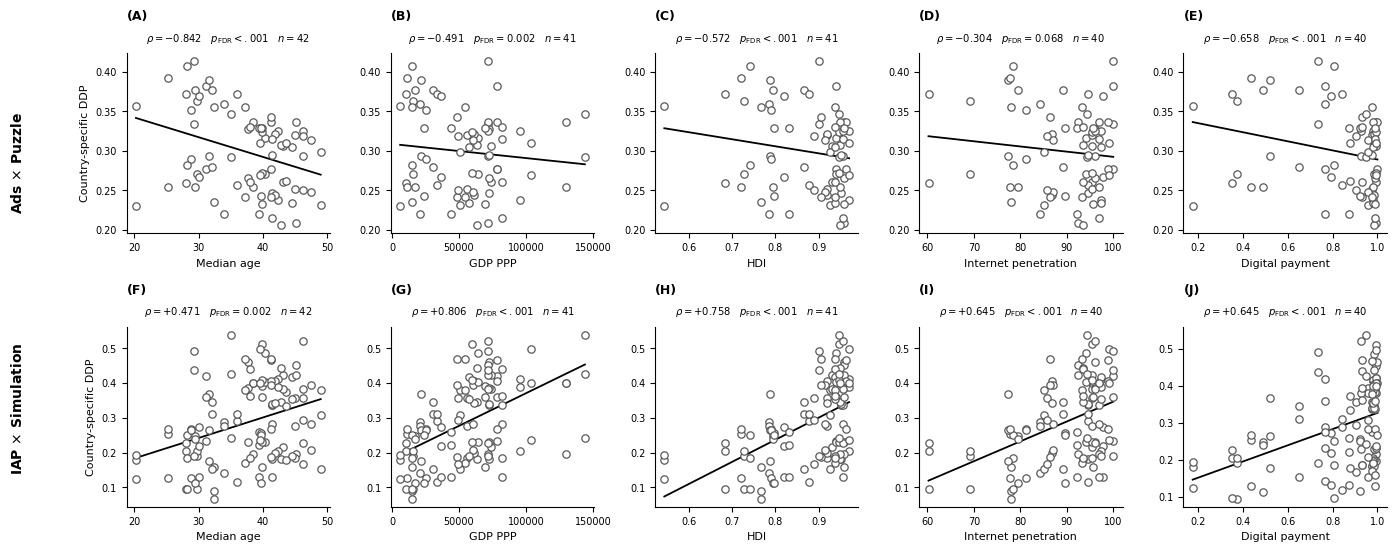

In [44]:
# ============================================================
# FIGURE:
# ADS vs IAP ACROSS FIVE NATIONAL CONTEXT INDICATORS
#
# Top row    = Ads × Puzzle
# Bottom row = IAP × Simulation
#
# Columns:
#   A/F = Median age
#   B/G = GDP PPP
#   C/H = HDI
#   D/I = Internet penetration
#   E/J = Digital payment
#
# Each point = one country
# Y-axis     = country-specific DDP
#
# Statistical inference:
#   Spearman's rho
#   BH-FDR-adjusted p-value
#
# Solid line = descriptive linear trend only
# ============================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. INDICATOR INFORMATION
# ============================================================

indicator_info = {

    "median_age": {
        "result_label": "Median age",
        "x_label": "Median age"
    },

    "gdp_ppp": {
        "result_label": "GDP PPP",
        "x_label": "GDP PPP"
    },

    "hdi": {
        "result_label": "HDI",
        "x_label": "HDI"
    },

    "internet_pen": {
        "result_label": "Internet penetration",
        "x_label": "Internet penetration"
    },

    "digital_pay": {
        "result_label": "Digital payment",
        "x_label": "Digital payment"
    }
}


# ============================================================
# 2. FUNCTION FOR ONE PANEL
# ============================================================

def draw_context_panel(
    ax,
    ddp_df,
    profile,
    genre,
    indicator,
    panel_letter
):

    # --------------------------------------------------------
    # Get national indicator
    # --------------------------------------------------------

    temp = ddp_df.copy()

    # Avoid duplicate contextual columns if function is rerun
    if indicator in temp.columns:
        temp = temp.drop(
            columns=[indicator]
        )

    temp = temp.merge(
        country_meta[
            ["country", indicator]
        ],
        on="country",
        how="left"
    )


    # --------------------------------------------------------
    # Keep complete cases
    # --------------------------------------------------------

    temp = temp[
        ["country", "DDP", indicator]
    ].dropna().copy()


    # --------------------------------------------------------
    # Get corresponding Spearman result
    # --------------------------------------------------------

    result_label = indicator_info[
        indicator
    ]["result_label"]

    stat_row = results[
        (results["Profile"] == profile)
        &
        (results["Genre"] == genre)
        &
        (results["Indicator"] == result_label)
    ].copy()

    if len(stat_row) != 1:

        raise ValueError(
            f"Expected one statistical result for "
            f"{profile}, {genre}, {result_label}; "
            f"found {len(stat_row)}."
        )


    rho = float(
        stat_row.iloc[0]["rho"]
    )

    p_fdr = float(
        stat_row.iloc[0]["p_fdr"]
    )

    n = int(
        stat_row.iloc[0]["n"]
    )


    # --------------------------------------------------------
    # Scatterplot
    # --------------------------------------------------------

    ax.scatter(
        temp[indicator],
        temp["DDP"],
        s=28,
        facecolors="white",
        edgecolors="0.35",
        linewidths=0.9,
        zorder=3
    )


    # --------------------------------------------------------
    # Descriptive linear trend
    # --------------------------------------------------------

    if len(temp) >= 2:

        x = temp[indicator].to_numpy(
            dtype=float
        )

        y = temp["DDP"].to_numpy(
            dtype=float
        )

        slope, intercept = np.polyfit(
            x,
            y,
            1
        )

        x_line = np.linspace(
            x.min(),
            x.max(),
            100
        )

        y_line = (
            slope * x_line
            +
            intercept
        )

        ax.plot(
            x_line,
            y_line,
            linewidth=1.3,
            color="black",
            zorder=2
        )


    # --------------------------------------------------------
    # Panel letter
    # --------------------------------------------------------

    ax.text(
        0.00,
        1.17,
        f"({panel_letter})",
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        clip_on=False
    )


    # --------------------------------------------------------
    # Statistical annotation
    #
    # IMPORTANT:
    # Placed ABOVE plot rather than inside it.
    # This prevents overlap with countries/trend lines.
    # --------------------------------------------------------

    if p_fdr < 0.001:

        p_text = (
            r"$p_{\mathrm{FDR}} < .001$"
        )

    else:

        p_text = (
            rf"$p_{{\mathrm{{FDR}}}}"
            rf" = {p_fdr:.3f}$"
        )


    stats_text = (
        rf"$\rho = {rho:+.3f}$"
        + "   "
        + p_text
        + "   "
        + rf"$n = {n}$"
    )


    ax.text(
        0.50,
        1.045,
        stats_text,
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=7.2,
        clip_on=False
    )


    # --------------------------------------------------------
    # Axis labels
    # --------------------------------------------------------

    ax.set_xlabel(
        indicator_info[
            indicator
        ]["x_label"],
        fontsize=8
    )

    ax.set_ylabel(
        r"Country-specific DDP",
        fontsize=8
    )


    # --------------------------------------------------------
    # Clean styling
    # --------------------------------------------------------

    ax.tick_params(
        axis="both",
        labelsize=7
    )

    ax.spines["top"].set_visible(
        False
    )

    ax.spines["right"].set_visible(
        False
    )

    ax.grid(
        False
    )


# ============================================================
# 3. CREATE 2 × 5 FIGURE
# ============================================================

fig, axes = plt.subplots(
    2,
    5,
    figsize=(14, 5.6)
)


# ============================================================
# 4. FIVE INDICATORS
# ============================================================

indicators = [

    "median_age",

    "gdp_ppp",

    "hdi",

    "internet_pen",

    "digital_pay"

]


# ============================================================
# 5. TOP ROW — ADS × PUZZLE
# ============================================================

top_letters = [
    "A",
    "B",
    "C",
    "D",
    "E"
]


for j, indicator in enumerate(
    indicators
):

    draw_context_panel(

        ax=axes[0, j],

        ddp_df=ads_country_ddp,

        profile="Ads-supported",

        genre="Puzzle",

        indicator=indicator,

        panel_letter=top_letters[j]
    )


# ============================================================
# 6. BOTTOM ROW — IAP × SIMULATION
# ============================================================

bottom_letters = [
    "F",
    "G",
    "H",
    "I",
    "J"
]


for j, indicator in enumerate(
    indicators
):

    draw_context_panel(

        ax=axes[1, j],

        ddp_df=iap_country_ddp,

        profile="IAP-supported",

        genre="Simulation",

        indicator=indicator,

        panel_letter=bottom_letters[j]
    )


# ============================================================
# 7. REMOVE REPEATED Y-AXIS LABELS
# ============================================================

for row in range(2):

    for col in range(1, 5):

        axes[
            row,
            col
        ].set_ylabel("")


# ============================================================
# 8. ROW LABELS
# ============================================================

fig.text(
    0.012,
    0.715,
    r"Ads $\times$ Puzzle",
    rotation=90,
    va="center",
    ha="center",
    fontsize=10,
    fontweight="bold"
)


fig.text(
    0.012,
    0.275,
    r"IAP $\times$ Simulation",
    rotation=90,
    va="center",
    ha="center",
    fontsize=10,
    fontweight="bold"
)


# ============================================================
# 9. SPACING
#
# Extra vertical space allows the rho / pFDR / n annotation
# to sit outside the plotting area without overlapping.
# ============================================================

fig.subplots_adjust(
    left=0.09,
    right=0.99,
    bottom=0.10,
    top=0.91,
    wspace=0.30,
    hspace=0.52
)


# ============================================================
# 10. SAVE
# ============================================================

plt.savefig(
    "ads_iap_five_context_indicators_fixed.pdf",
    bbox_inches="tight"
)


plt.savefig(
    "ads_iap_five_context_indicators_fixed.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

# -----------------------------------------------------------------------

# Illustrative Examples for Results

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# INTERACTION-ANALYSIS FRAMEWORK
# COMPLETE WORKED EXAMPLE + CONTEXTUAL FIGURE
# ============================================================

df = apps.copy()
Z = 1.96


# ============================================================
# 0. DISPLAY NAMES
# ============================================================

def variable_names(exposure, genre, outcome):

    exposure_names = {
        "contains_ads": "Ads",
        "offers_iap": "IAP"
    }

    outcome_names = {
        "install_success": "Install Success",
        "rating_success": "Rating Success"
    }

    r_name = exposure_names.get(exposure, exposure)
    y_name = outcome_names.get(outcome, outcome)

    return {
        "r": r_name,
        "rbar": f"{r_name} absent",
        "c": genre,
        "cbar": f"Non-{genre}",
        "y": y_name
    }


# ============================================================
# 1. BASIC HELPERS
# ============================================================

def safe_div(num, den):
    return num / den if den != 0 else np.nan


def apply_correction_if_needed(a, b, c, d, correction=0.5):
    """
    Haldane--Anscombe correction.
    Add 0.5 to all four cells only when any cell is zero.
    """
    if any(x == 0 for x in [a, b, c, d]):
        return (
            a + correction,
            b + correction,
            c + correction,
            d + correction,
            True
        )

    return a, b, c, d, False


def se_prob_diff(p1, n1, p2, n2):

    if n1 == 0 or n2 == 0:
        return np.nan

    return np.sqrt(
        p1 * (1 - p1) / n1 +
        p2 * (1 - p2) / n2
    )


def se_log_or(a, b, c, d):
    return np.sqrt(
        1/a + 1/b + 1/c + 1/d
    )


# ============================================================
# 2. CLASSIFICATION FUNCTIONS
# ============================================================

def classify_ddp(ddp, se):

    if np.isnan(ddp) or np.isnan(se):
        return "NA"

    low = ddp - Z * se
    high = ddp + Z * se

    if low > 0:
        return "+"
    elif high < 0:
        return "-"
    else:
        return "0"


def classify_ror(log_ror, se_log_ror):

    if np.isnan(log_ror) or np.isnan(se_log_ror):
        return "NA"

    low = log_ror - Z * se_log_ror
    high = log_ror + Z * se_log_ror

    if low > 0:
        return "+"
    elif high < 0:
        return "-"
    else:
        return "0"


def joint_pattern(ddp_direction, ror_direction):

    if "NA" in (ddp_direction, ror_direction):
        return "NA"

    return ddp_direction + ror_direction


def compact_interaction(pattern):

    if pattern == "++":
        return "+"

    if pattern == "--":
        return "-"

    if pattern == "00":
        return "0"

    if pattern == "NA":
        return "NA"

    return "M"


# ============================================================
# 3. BUILD ONE 2 × 2 TABLE
# ============================================================

def build_2x2(data, exposure, outcome, names):

    # r and y
    a = (
        (data[exposure] == 1) &
        (data[outcome] == 1)
    ).sum()

    # r and y-bar
    b = (
        (data[exposure] == 1) &
        (data[outcome] == 0)
    ).sum()

    # r-bar and y
    c = (
        (data[exposure] == 0) &
        (data[outcome] == 1)
    ).sum()

    # r-bar and y-bar
    d = (
        (data[exposure] == 0) &
        (data[outcome] == 0)
    ).sum()

    # Explicit notation rather than
    # "Exposure" and "No Exposure"
    table = pd.DataFrame(
        {
            f"{names['r']} (r)": [a, b],
            f"{names['r']} absent (r\u0305)": [c, d]
        },
        index=[
            f"{names['y']} (y)",
            f"{names['y']} absent (y\u0305)"
        ]
    )

    table["Total"] = table.sum(axis=1)
    table.loc["Total"] = table.sum(axis=0)

    return table, (a, b, c, d)


# ============================================================
# 4. CALCULATE FULL INTERACTION STATISTICS
# ============================================================

def calculate_interaction(data, exposure, genre, outcome):

    names = variable_names(
        exposure,
        genre,
        outcome
    )

    focal = data[data["genre"] == genre].copy()
    rest = data[data["genre"] != genre].copy()

    # --------------------------------------------------------
    # STEP 1: 2 × 2 tables
    # --------------------------------------------------------

    focal_table, focal_cells = build_2x2(
        focal,
        exposure,
        outcome,
        names
    )

    rest_table, rest_cells = build_2x2(
        rest,
        exposure,
        outcome,
        names
    )

    a1, b1, c1, d1 = focal_cells
    a0, b0, c0, d0 = rest_cells


    # --------------------------------------------------------
    # STEP 2: conditional probabilities
    # --------------------------------------------------------

    n_r_c = a1 + b1
    n_rbar_c = c1 + d1

    n_r_cbar = a0 + b0
    n_rbar_cbar = c0 + d0

    p_y_r_c = safe_div(a1, n_r_c)
    p_y_rbar_c = safe_div(c1, n_rbar_c)

    p_y_r_cbar = safe_div(a0, n_r_cbar)
    p_y_rbar_cbar = safe_div(c0, n_rbar_cbar)


    # --------------------------------------------------------
    # STEP 3: within-stratum probability differences
    # --------------------------------------------------------

    dp_c = p_y_r_c - p_y_rbar_c

    dp_cbar = (
        p_y_r_cbar -
        p_y_rbar_cbar
    )

    se_dp_c = se_prob_diff(
        p_y_r_c,
        n_r_c,
        p_y_rbar_c,
        n_rbar_c
    )

    se_dp_cbar = se_prob_diff(
        p_y_r_cbar,
        n_r_cbar,
        p_y_rbar_cbar,
        n_rbar_cbar
    )

    dp_c_low = dp_c - Z * se_dp_c
    dp_c_high = dp_c + Z * se_dp_c

    dp_cbar_low = dp_cbar - Z * se_dp_cbar
    dp_cbar_high = dp_cbar + Z * se_dp_cbar


    # --------------------------------------------------------
    # STEP 4: conditional odds ratios
    # --------------------------------------------------------

    A1, B1, C1, D1, corrected_c = \
        apply_correction_if_needed(
            a1, b1, c1, d1
        )

    A0, B0, C0, D0, corrected_cbar = \
        apply_correction_if_needed(
            a0, b0, c0, d0
        )

    OR_c = safe_div(
        A1 * D1,
        B1 * C1
    )

    OR_cbar = safe_div(
        A0 * D0,
        B0 * C0
    )

    log_OR_c = np.log(OR_c)
    log_OR_cbar = np.log(OR_cbar)

    se_log_OR_c = se_log_or(
        A1, B1, C1, D1
    )

    se_log_OR_cbar = se_log_or(
        A0, B0, C0, D0
    )

    OR_c_low = np.exp(
        log_OR_c -
        Z * se_log_OR_c
    )

    OR_c_high = np.exp(
        log_OR_c +
        Z * se_log_OR_c
    )

    OR_cbar_low = np.exp(
        log_OR_cbar -
        Z * se_log_OR_cbar
    )

    OR_cbar_high = np.exp(
        log_OR_cbar +
        Z * se_log_OR_cbar
    )


    # --------------------------------------------------------
    # STEP 5: additive interaction
    # DDP
    # --------------------------------------------------------

    DDP = dp_c - dp_cbar

    se_DDP = np.sqrt(
        se_dp_c**2 +
        se_dp_cbar**2
    )

    DDP_low = DDP - Z * se_DDP
    DDP_high = DDP + Z * se_DDP

    DDP_direction = classify_ddp(
        DDP,
        se_DDP
    )


    # --------------------------------------------------------
    # STEP 6: multiplicative interaction
    # RoR
    # --------------------------------------------------------

    RoR = safe_div(
        OR_c,
        OR_cbar
    )

    log_RoR = np.log(RoR)

    se_log_RoR = np.sqrt(
        se_log_OR_c**2 +
        se_log_OR_cbar**2
    )

    log_RoR_low = (
        log_RoR -
        Z * se_log_RoR
    )

    log_RoR_high = (
        log_RoR +
        Z * se_log_RoR
    )

    RoR_low = np.exp(log_RoR_low)
    RoR_high = np.exp(log_RoR_high)

    RoR_direction = classify_ror(
        log_RoR,
        se_log_RoR
    )


    # --------------------------------------------------------
    # STEP 7: joint interpretation
    # --------------------------------------------------------

    joint = joint_pattern(
        DDP_direction,
        RoR_direction
    )

    interaction = compact_interaction(
        joint
    )


    return {

        "names": names,

        "focal_table": focal_table,
        "rest_table": rest_table,

        "cells_c": focal_cells,
        "cells_cbar": rest_cells,

        "p_y_r_c": p_y_r_c,
        "p_y_rbar_c": p_y_rbar_c,
        "p_y_r_cbar": p_y_r_cbar,
        "p_y_rbar_cbar": p_y_rbar_cbar,

        "dp_c": dp_c,
        "dp_c_low": dp_c_low,
        "dp_c_high": dp_c_high,

        "dp_cbar": dp_cbar,
        "dp_cbar_low": dp_cbar_low,
        "dp_cbar_high": dp_cbar_high,

        "OR_c": OR_c,
        "OR_c_low": OR_c_low,
        "OR_c_high": OR_c_high,

        "OR_cbar": OR_cbar,
        "OR_cbar_low": OR_cbar_low,
        "OR_cbar_high": OR_cbar_high,

        "DDP": DDP,
        "DDP_low": DDP_low,
        "DDP_high": DDP_high,
        "DDP_direction": DDP_direction,

        "RoR": RoR,
        "RoR_low": RoR_low,
        "RoR_high": RoR_high,
        "RoR_direction": RoR_direction,

        "joint": joint,
        "interaction": interaction,

        "corrected_c": corrected_c,
        "corrected_cbar": corrected_cbar
    }


# ============================================================
# 5. PRINT ALL SEVEN STEPS
# ============================================================

def worked_example(
    df,
    country,
    exposure,
    genre,
    outcome
):

    data = df[
        df["country"] == country
    ].copy()

    R = calculate_interaction(
        data,
        exposure,
        genre,
        outcome
    )

    n = R["names"]

    print("=" * 95)
    print(
        f"WORKED EXAMPLE: "
        f"{n['r']} × {n['c']} → {n['y']}"
    )
    print(f"Country = {country}")
    print("=" * 95)

    # --------------------------------------------------------
    # Define notation first
    # --------------------------------------------------------

    print("\nFRAMEWORK NOTATION")
    print("-" * 95)

    print(
        f"r      = {n['r']} present"
    )

    print(
        f"r̄      = {n['r']} absent"
    )

    print(
        f"c      = {n['c']}"
    )

    print(
        f"c̄      = {n['cbar']}"
    )

    print(
        f"y      = {n['y']}"
    )

    print(
        f"ȳ      = {n['y']} absent"
    )


    # ========================================================
    # STEP 1
    # ========================================================

    print("\n" + "=" * 95)
    print(
        "STEP 1: CONSTRUCT STRATUM-SPECIFIC "
        "2 × 2 CONTINGENCY TABLES"
    )
    print("=" * 95)

    print(
        f"\nStratum c = {n['c']}"
    )

    display(R["focal_table"])

    print(
        f"\nStratum c̄ = {n['cbar']}"
    )

    display(R["rest_table"])


    # ========================================================
    # STEP 2
    # ========================================================

    print("\n" + "=" * 95)
    print(
        "STEP 2: ESTIMATE CONDITIONAL "
        "SUCCESS PROBABILITIES"
    )
    print("=" * 95)

    print(
        f"P(y | r, c) "
        f"= P({n['y']} | {n['r']}, {n['c']}) "
        f"= {R['p_y_r_c']:.3f}"
    )

    print(
        f"P(y | r̄, c) "
        f"= P({n['y']} | {n['r']} absent, {n['c']}) "
        f"= {R['p_y_rbar_c']:.3f}"
    )

    print()

    print(
        f"P(y | r, c̄) "
        f"= P({n['y']} | {n['r']}, {n['cbar']}) "
        f"= {R['p_y_r_cbar']:.3f}"
    )

    print(
        f"P(y | r̄, c̄) "
        f"= P({n['y']} | {n['r']} absent, {n['cbar']}) "
        f"= {R['p_y_rbar_cbar']:.3f}"
    )


    # ========================================================
    # STEP 3
    # ========================================================

    print("\n" + "=" * 95)
    print(
        "STEP 3: ESTIMATE WITHIN-STRATUM "
        "DIFFERENCES IN SUCCESS PROBABILITY"
    )
    print("=" * 95)

    print(
        f"Δp_(r|c)"
        f" = P(y | r,c) - P(y | r̄,c)"
    )

    print(
        f"         = {R['p_y_r_c']:.3f}"
        f" - {R['p_y_rbar_c']:.3f}"
    )

    print(
        f"         = {R['dp_c']:.3f}"
        f"  [95% CI: "
        f"{R['dp_c_low']:.3f}, "
        f"{R['dp_c_high']:.3f}]"
    )

    print()

    print(
        f"Δp_(r|c̄)"
        f" = P(y | r,c̄) - P(y | r̄,c̄)"
    )

    print(
        f"          = {R['p_y_r_cbar']:.3f}"
        f" - {R['p_y_rbar_cbar']:.3f}"
    )

    print(
        f"          = {R['dp_cbar']:.3f}"
        f"  [95% CI: "
        f"{R['dp_cbar_low']:.3f}, "
        f"{R['dp_cbar_high']:.3f}]"
    )


    # ========================================================
    # STEP 4
    # ========================================================

    print("\n" + "=" * 95)
    print(
        "STEP 4: ESTIMATE CONDITIONAL ODDS RATIOS"
    )
    print("=" * 95)

    print(
        f"OR_(r|c) for {n['c']}"
        f" = {R['OR_c']:.3f}"
        f"  [95% CI: "
        f"{R['OR_c_low']:.3f}, "
        f"{R['OR_c_high']:.3f}]"
    )

    print(
        f"OR_(r|c̄) for {n['cbar']}"
        f" = {R['OR_cbar']:.3f}"
        f"  [95% CI: "
        f"{R['OR_cbar_low']:.3f}, "
        f"{R['OR_cbar_high']:.3f}]"
    )

    if R["corrected_c"]:
        print(
            f"\n0.5 Haldane--Anscombe correction "
            f"was applied to the {n['c']} table."
        )

    if R["corrected_cbar"]:
        print(
            f"\n0.5 Haldane--Anscombe correction "
            f"was applied to the {n['cbar']} table."
        )

    if (
        not R["corrected_c"] and
        not R["corrected_cbar"]
    ):
        print(
            "\nNo zero-cell correction was required."
        )


    # ========================================================
    # STEP 5
    # ========================================================

    print("\n" + "=" * 95)
    print(
        "STEP 5: ESTIMATE ADDITIVE INTERACTION (DDP)"
    )
    print("=" * 95)

    print(
        "DDP = Δp_(r|c) - Δp_(r|c̄)"
    )

    print(
        f"    = {R['dp_c']:.3f}"
        f" - ({R['dp_cbar']:.3f})"
    )

    print(
        f"    = {R['DDP']:.3f}"
    )

    print(
        f"95% CI = "
        f"[{R['DDP_low']:.3f}, "
        f"{R['DDP_high']:.3f}]"
    )

    print(
        f"Additive interaction classification "
        f"= {R['DDP_direction']}"
    )


    # ========================================================
    # STEP 6
    # ========================================================

    print("\n" + "=" * 95)
    print(
        "STEP 6: ESTIMATE MULTIPLICATIVE "
        "INTERACTION (RoR)"
    )
    print("=" * 95)

    print(
        "RoR = OR_(r|c) / OR_(r|c̄)"
    )

    print(
        f"    = {R['OR_c']:.3f}"
        f" / {R['OR_cbar']:.3f}"
    )

    print(
        f"    = {R['RoR']:.3f}"
    )

    print(
        f"95% CI = "
        f"[{R['RoR_low']:.3f}, "
        f"{R['RoR_high']:.3f}]"
    )

    print(
        f"Multiplicative interaction classification "
        f"= {R['RoR_direction']}"
    )


    # ========================================================
    # STEP 7
    # ========================================================

    print("\n" + "=" * 95)
    print(
        "STEP 7: INTERPRET EVIDENCE ACROSS BOTH SCALES"
    )
    print("=" * 95)

    print(
        f"Additive scale (DDP)       "
        f"= {R['DDP_direction']}"
    )

    print(
        f"Multiplicative scale (RoR) "
        f"= {R['RoR_direction']}"
    )

    print(
        f"Joint interaction pattern  "
        f"= {R['joint']}"
    )

    print(
        f"Overall interaction class  "
        f"= {R['interaction']}"
    )

    print("=" * 95)

    return R


# ============================================================
# 6. COUNTRY-SPECIFIC RESULTS FROM SCRATCH
# ============================================================

def interaction_by_country(
    df,
    exposure,
    genre,
    outcome
):

    rows = []

    for country in sorted(
        df["country"].dropna().unique()
    ):

        data = df[
            df["country"] == country
        ].copy()

        R = calculate_interaction(
            data,
            exposure,
            genre,
            outcome
        )

        rows.append({
            "country": country,

            "DDP": R["DDP"],
            "DDP_low": R["DDP_low"],
            "DDP_high": R["DDP_high"],
            "DDP_direction": R["DDP_direction"],

            "RoR": R["RoR"],
            "RoR_low": R["RoR_low"],
            "RoR_high": R["RoR_high"],
            "RoR_direction": R["RoR_direction"],

            "joint": R["joint"],
            "interaction": R["interaction"]
        })

    return pd.DataFrame(rows)


# ============================================================
# 7. MONTH-SPECIFIC RESULTS FROM SCRATCH
# ============================================================

def interaction_by_month(
    df,
    country,
    exposure,
    genre,
    outcome
):

    data = df[
        df["country"] == country
    ].copy()

    rows = []

    for month in sorted(
        data["month"].dropna().unique()
    ):

        sub = data[
            data["month"] == month
        ].copy()

        R = calculate_interaction(
            sub,
            exposure,
            genre,
            outcome
        )

        rows.append({
            "month": month,

            "DDP": R["DDP"],
            "DDP_low": R["DDP_low"],
            "DDP_high": R["DDP_high"],
            "DDP_direction": R["DDP_direction"],

            "RoR": R["RoR"],
            "RoR_low": R["RoR_low"],
            "RoR_high": R["RoR_high"],
            "RoR_direction": R["RoR_direction"],

            "joint": R["joint"],
            "interaction": R["interaction"]
        })

    return pd.DataFrame(rows)


# ============================================================
# 8. MAIN-PAPER FIGURE
# COUNTRY + TEMPORAL ADDITIVE INTERACTION (DDP)
#
# Panel A = country-specific DDP as sorted bars
# Panel B = monthly DDP as temporal line
#
# RoR figures can be reported in Supplementary Material.
# ============================================================

def plot_interaction_profile_main(
    df,
    exposure,
    genre,
    outcome,
    country_for_month,
    filename
):

    # --------------------------------------------------------
    # Calculate results
    # --------------------------------------------------------

    countries = interaction_by_country(
        df,
        exposure,
        genre,
        outcome
    )

    months = interaction_by_month(
        df,
        country_for_month,
        exposure,
        genre,
        outcome
    )


    # --------------------------------------------------------
    # Sort
    # --------------------------------------------------------

    countries = (
        countries
        .sort_values("DDP")
        .reset_index(drop=True)
    )

    months = (
        months
        .sort_values("month")
        .reset_index(drop=True)
    )


    # ========================================================
    # FIGURE
    # ========================================================

    fig, (ax1, ax2) = plt.subplots(
        1,
        2,
        figsize=(12.5, 4.3),
        gridspec_kw={
            "width_ratios": [1.35, 1]
        }
    )


    # ========================================================
    # PANEL A
    # DDP ACROSS COUNTRIES — BAR/HISTOGRAM STYLE
    # ========================================================

    x = np.arange(
        len(countries)
    )

    yerr = np.vstack([
        countries["DDP"] - countries["DDP_low"],
        countries["DDP_high"] - countries["DDP"]
    ])


    ax1.bar(
        x,
        countries["DDP"],
        width=0.78,
        color="0.55",
        edgecolor="0.35",
        linewidth=0.35,
        zorder=2
    )


    # 95% CI
    ax1.errorbar(
        x,
        countries["DDP"],
        yerr=yerr,
        fmt="none",
        ecolor="0.25",
        elinewidth=0.65,
        capsize=1.5,
        capthick=0.65,
        zorder=3
    )


    # DDP = 0 null
    ax1.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=0.8,
        zorder=1
    )


    # Country labels
    ax1.set_xticks(x)

    ax1.set_xticklabels(
        countries["country"],
        rotation=90,
        fontsize=5.5
    )


    ax1.set_ylabel(
        r"$\widehat{\mathrm{DDP}}$",
        fontsize=9
    )

    ax1.set_xlabel(
        "National market",
        fontsize=9
    )


    ax1.set_title(
        "(A) Cross-country variation",
        loc="left",
        fontsize=10,
        fontweight="bold",
        pad=20
    )


    ax1.annotate(
        r"Null: $\widehat{\mathrm{DDP}}=0$",
        xy=(0.01, 0),
        xycoords=("axes fraction", "data"),
        xytext=(0, 4),
        textcoords="offset points",
        ha="left",
        va="bottom",
        fontsize=7
    )


    # Small margins around first/last bars
    ax1.set_xlim(
        -0.7,
        len(countries) - 0.3
    )


    # ========================================================
    # PANEL B
    # DDP OVER TIME
    # ========================================================

    x_month = np.arange(
        len(months)
    )

    month_yerr = np.vstack([
        months["DDP"] - months["DDP_low"],
        months["DDP_high"] - months["DDP"]
    ])


    ax2.errorbar(
        x_month,
        months["DDP"],
        yerr=month_yerr,

        fmt="o-",

        color="0.25",

        markerfacecolor="0.25",
        markeredgecolor="0.25",

        markersize=3.5,
        linewidth=1.1,

        ecolor="0.55",
        elinewidth=0.8,
        capsize=2,

        zorder=3
    )


    # DDP = 0 null
    ax2.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=0.8,
        zorder=1
    )


    # Month labels
    month_labels = (
        pd.to_datetime(
            months["month"]
        )
        .dt.strftime("%b\n%Y")
    )


    ax2.set_xticks(
        x_month
    )

    ax2.set_xticklabels(
        month_labels,
        fontsize=6.5
    )


    ax2.set_ylabel(
        r"$\widehat{\mathrm{DDP}}$",
        fontsize=9
    )

    ax2.set_xlabel(
        "Month",
        fontsize=9
    )


    ax2.set_title(
        f"(B) Temporal variation ({country_for_month})",
        loc="left",
        fontsize=10,
        fontweight="bold",
        pad=20
    )


    ax2.annotate(
        r"Null: $\widehat{\mathrm{DDP}}=0$",
        xy=(0.01, 0),
        xycoords=("axes fraction", "data"),
        xytext=(0, 4),
        textcoords="offset points",
        ha="left",
        va="bottom",
        fontsize=7
    )


    # ========================================================
    # CLEAN PAPER STYLE
    # ========================================================

    for ax in [ax1, ax2]:

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.tick_params(
            axis="y",
            labelsize=7
        )

        # Very light horizontal guides only
        ax.yaxis.grid(
            True,
            linewidth=0.35,
            alpha=0.18,
            zorder=0
        )

        ax.xaxis.grid(False)


    # ========================================================
    # LAYOUT
    # ========================================================

    fig.subplots_adjust(
        left=0.07,
        right=0.99,
        bottom=0.20,
        top=0.91,
        wspace=0.24
    )


    # ========================================================
    # SAVE
    # ========================================================

    plt.savefig(
        f"{filename}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.savefig(
        f"{filename}.pdf",
        bbox_inches="tight"
    )

    plt.show()


    return countries, months

WORKED EXAMPLE: IAP × Sports → Install Success
Country = IN

FRAMEWORK NOTATION
-----------------------------------------------------------------------------------------------
r      = IAP present
r̄      = IAP absent
c      = Sports
c̄      = Non-Sports
y      = Install Success
ȳ      = Install Success absent

STEP 1: CONSTRUCT STRATUM-SPECIFIC 2 × 2 CONTINGENCY TABLES

Stratum c = Sports


,IAP (r),IAP absent (r̅),Total
Install Success (y),691,513,1204
Install Success absent (y̅),452,1592,2044
Total,1143,2105,3248



Stratum c̄ = Non-Sports


,IAP (r),IAP absent (r̅),Total
Install Success (y),4875,15103,19978
Install Success absent (y̅),7641,11483,19124
Total,12516,26586,39102



STEP 2: ESTIMATE CONDITIONAL SUCCESS PROBABILITIES
P(y | r, c) = P(Install Success | IAP, Sports) = 0.605
P(y | r̄, c) = P(Install Success | IAP absent, Sports) = 0.244

P(y | r, c̄) = P(Install Success | IAP, Non-Sports) = 0.390
P(y | r̄, c̄) = P(Install Success | IAP absent, Non-Sports) = 0.568

STEP 3: ESTIMATE WITHIN-STRATUM DIFFERENCES IN SUCCESS PROBABILITY
Δp_(r|c) = P(y | r,c) - P(y | r̄,c)
         = 0.605 - 0.244
         = 0.361  [95% CI: 0.327, 0.395]

Δp_(r|c̄) = P(y | r,c̄) - P(y | r̄,c̄)
          = 0.390 - 0.568
          = -0.179  [95% CI: -0.189, -0.168]

STEP 4: ESTIMATE CONDITIONAL ODDS RATIOS
OR_(r|c) for Sports = 4.744  [95% CI: 4.064, 5.538]
OR_(r|c̄) for Non-Sports = 0.485  [95% CI: 0.465, 0.507]

No zero-cell correction was required.

STEP 5: ESTIMATE ADDITIVE INTERACTION (DDP)
DDP = Δp_(r|c) - Δp_(r|c̄)
    = 0.361 - (-0.179)
    = 0.539
95% CI = [0.504, 0.575]
Additive interaction classification = +

STEP 6: ESTIMATE MULTIPLICATIVE INTERACTION (RoR)
RoR = OR

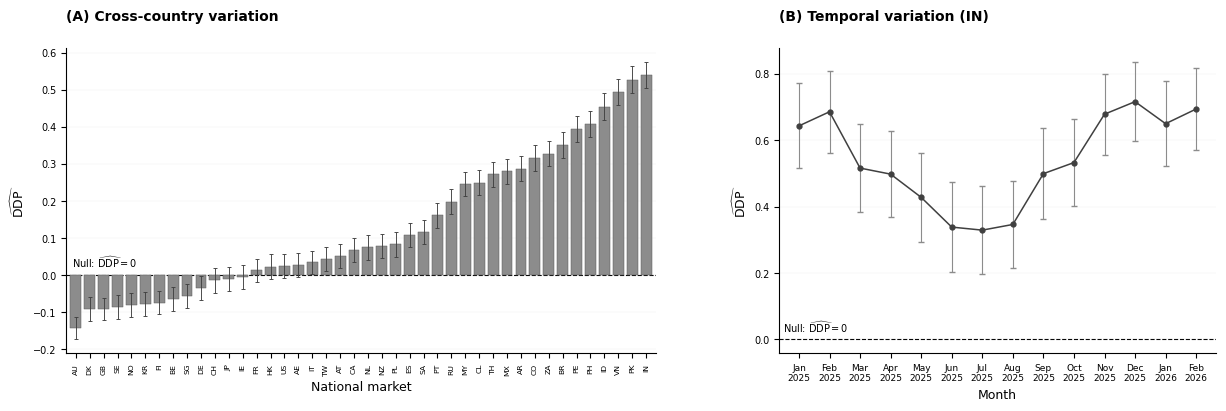

In [65]:
# ============================================================
# HETEROGENEOUS PROFILE
# IAP × SPORTS → INSTALL SUCCESS
# Worked example uses India, where interaction is ++
# ============================================================

iap_sports_IN = worked_example(
    df=df,
    country="IN",
    exposure="offers_iap",
    genre="Sports",
    outcome="install_success"
)

countries_iap_sports, months_iap_sports = plot_interaction_profile_main(
    df=apps,
    exposure="offers_iap",
    genre="Sports",
    outcome="install_success",
    country_for_month="IN",
    filename="iap_sports_main"
)

WORKED EXAMPLE: IAP × RPG → Install Success
Country = US

FRAMEWORK NOTATION
-----------------------------------------------------------------------------------------------
r      = IAP present
r̄      = IAP absent
c      = RPG
c̄      = Non-RPG
y      = Install Success
ȳ      = Install Success absent

STEP 1: CONSTRUCT STRATUM-SPECIFIC 2 × 2 CONTINGENCY TABLES

Stratum c = RPG


,IAP (r),IAP absent (r̅),Total
Install Success (y),1916,150,2066
Install Success absent (y̅),838,274,1112
Total,2754,424,3178



Stratum c̄ = Non-RPG


,IAP (r),IAP absent (r̅),Total
Install Success (y),10287,8829,19116
Install Success absent (y̅),12696,7360,20056
Total,22983,16189,39172



STEP 2: ESTIMATE CONDITIONAL SUCCESS PROBABILITIES
P(y | r, c) = P(Install Success | IAP, RPG) = 0.696
P(y | r̄, c) = P(Install Success | IAP absent, RPG) = 0.354

P(y | r, c̄) = P(Install Success | IAP, Non-RPG) = 0.448
P(y | r̄, c̄) = P(Install Success | IAP absent, Non-RPG) = 0.545

STEP 3: ESTIMATE WITHIN-STRATUM DIFFERENCES IN SUCCESS PROBABILITY
Δp_(r|c) = P(y | r,c) - P(y | r̄,c)
         = 0.696 - 0.354
         = 0.342  [95% CI: 0.293, 0.391]

Δp_(r|c̄) = P(y | r,c̄) - P(y | r̄,c̄)
          = 0.448 - 0.545
          = -0.098  [95% CI: -0.108, -0.088]

STEP 4: ESTIMATE CONDITIONAL ODDS RATIOS
OR_(r|c) for RPG = 4.176  [95% CI: 3.369, 5.178]
OR_(r|c̄) for Non-RPG = 0.675  [95% CI: 0.649, 0.703]

No zero-cell correction was required.

STEP 5: ESTIMATE ADDITIVE INTERACTION (DDP)
DDP = Δp_(r|c) - Δp_(r|c̄)
    = 0.342 - (-0.098)
    = 0.440
95% CI = [0.390, 0.489]
Additive interaction classification = +

STEP 6: ESTIMATE MULTIPLICATIVE INTERACTION (RoR)
RoR = OR_(r|c) / OR_(r|c̄)

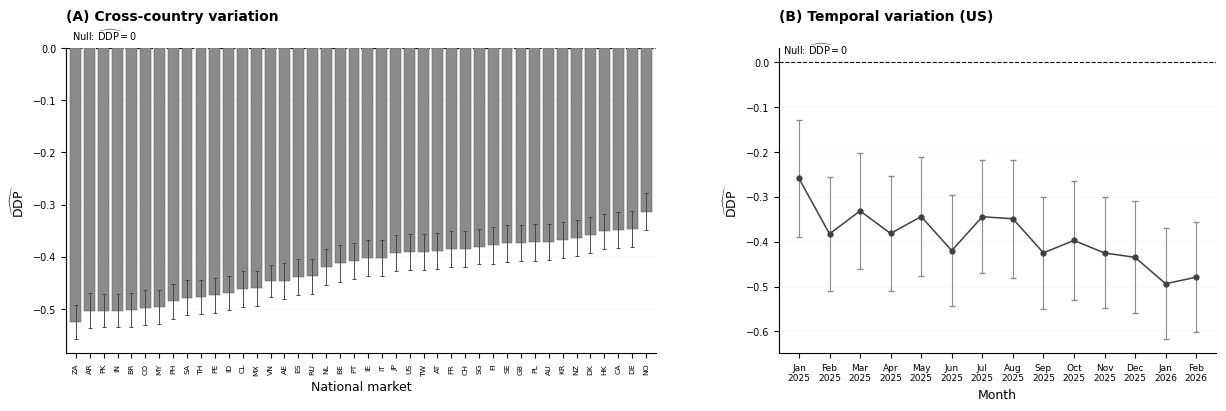

In [67]:
# ============================================================
# POSITIVE PROFILE
# IAP × RPG → INSTALL SUCCESS
# ============================================================

iap_rpg_US = worked_example(
    df=df,
    country="US",
    exposure="offers_iap",
    genre="RPG",
    outcome="install_success"
)


countries_ads_rpg, months_ads_rpg = plot_interaction_profile_main(
    df=apps,
    exposure="contains_ads",
    genre="RPG",
    outcome="install_success",
    country_for_month="US",
    filename="ads_rpg_main"
)

WORKED EXAMPLE: Ads × RPG → Install Success
Country = US

FRAMEWORK NOTATION
-----------------------------------------------------------------------------------------------
r      = Ads present
r̄      = Ads absent
c      = RPG
c̄      = Non-RPG
y      = Install Success
ȳ      = Install Success absent

STEP 1: CONSTRUCT STRATUM-SPECIFIC 2 × 2 CONTINGENCY TABLES

Stratum c = RPG


,Ads (r),Ads absent (r̅),Total
Install Success (y),629,1437,2066
Install Success absent (y̅),724,388,1112
Total,1353,1825,3178



Stratum c̄ = Non-RPG


,Ads (r),Ads absent (r̅),Total
Install Success (y),12262,6854,19116
Install Success absent (y̅),11554,8502,20056
Total,23816,15356,39172



STEP 2: ESTIMATE CONDITIONAL SUCCESS PROBABILITIES
P(y | r, c) = P(Install Success | Ads, RPG) = 0.465
P(y | r̄, c) = P(Install Success | Ads absent, RPG) = 0.787

P(y | r, c̄) = P(Install Success | Ads, Non-RPG) = 0.515
P(y | r̄, c̄) = P(Install Success | Ads absent, Non-RPG) = 0.446

STEP 3: ESTIMATE WITHIN-STRATUM DIFFERENCES IN SUCCESS PROBABILITY
Δp_(r|c) = P(y | r,c) - P(y | r̄,c)
         = 0.465 - 0.787
         = -0.323  [95% CI: -0.355, -0.290]

Δp_(r|c̄) = P(y | r,c̄) - P(y | r̄,c̄)
          = 0.515 - 0.446
          = 0.069  [95% CI: 0.058, 0.079]

STEP 4: ESTIMATE CONDITIONAL ODDS RATIOS
OR_(r|c) for RPG = 0.235  [95% CI: 0.201, 0.274]
OR_(r|c̄) for Non-RPG = 1.316  [95% CI: 1.264, 1.371]

No zero-cell correction was required.

STEP 5: ESTIMATE ADDITIVE INTERACTION (DDP)
DDP = Δp_(r|c) - Δp_(r|c̄)
    = -0.323 - (0.069)
    = -0.391
95% CI = [-0.425, -0.357]
Additive interaction classification = -

STEP 6: ESTIMATE MULTIPLICATIVE INTERACTION (RoR)
RoR = OR_(r|c) / OR_(r|

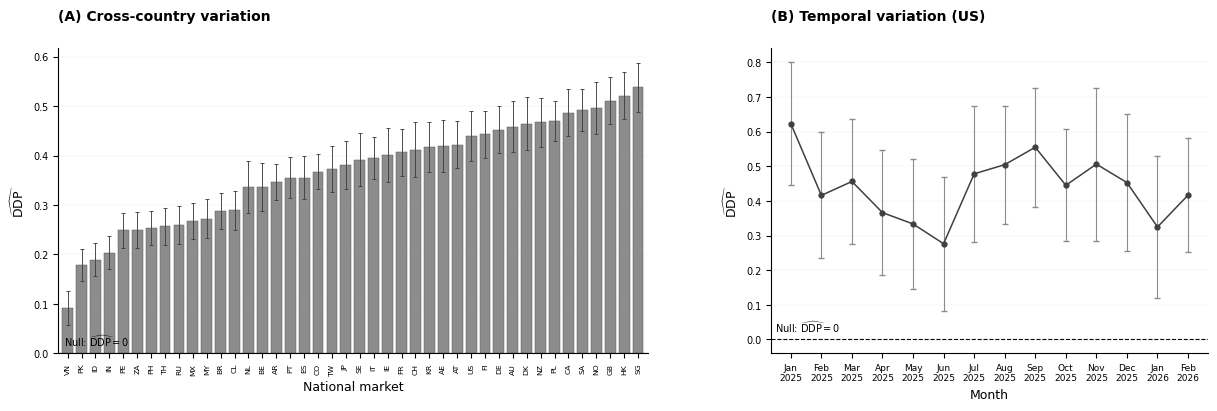

In [3]:
# ============================================================
# NEGATIVE PROFILE
# # ADS × RPG → INSTALL SUCCESS
# ============================================================

ads_rpg_US = worked_example(
    df=df,
    country="US",
    exposure="contains_ads",
    genre="RPG",
    outcome="install_success"
)

countries_iap_rpg, months_iap_rpg = plot_interaction_profile_main(
    df=apps,
    exposure="offers_iap",
    genre="RPG",
    outcome="install_success",
    country_for_month="US",
    filename="iap_rpg_main"
)


In [32]:
# ============================================================
# RPG MONETIZATION COMPARISON — INTUITIVE VERSION
#
# (A) Ads × RPG
# (B) IAP × RPG
# (C) Pooled vs RPG-specific IAP
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter


def plot_rpg_monetization_comparison(
    df,
    country="US",
    outcome="install_success",
    filename="rpg_monetization_comparison"
):

    data = df[
        df["country"] == country
    ].copy()


    # ========================================================
    # CALCULATE INTERACTIONS
    # ========================================================

    R_ads = calculate_interaction(
        data,
        exposure="contains_ads",
        genre="RPG",
        outcome=outcome
    )

    R_iap = calculate_interaction(
        data,
        exposure="offers_iap",
        genre="RPG",
        outcome=outcome
    )


    # ========================================================
    # POOLED IAP
    # ========================================================

    pooled_no_iap = data.loc[
        data["offers_iap"] == 0,
        outcome
    ].mean()

    pooled_iap = data.loc[
        data["offers_iap"] == 1,
        outcome
    ].mean()

    pooled_diff = pooled_iap - pooled_no_iap


    # ========================================================
    # FIGURE
    # ========================================================

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(14.8, 5),
        sharey=True
    )

    ax1, ax2, ax3 = axes
    x = np.array([0, 1])


    # ========================================================
    # HELPER — PANELS A AND B
    # ========================================================

    def interaction_panel(
        ax,
        R,
        exposure_label,
        title
    ):

        rpg_probs = np.array([
            R["p_y_rbar_c"],
            R["p_y_r_c"]
        ])

        non_rpg_probs = np.array([
            R["p_y_rbar_cbar"],
            R["p_y_r_cbar"]
        ])

        rpg_diff = (
            R["p_y_r_c"] -
            R["p_y_rbar_c"]
        )

        non_rpg_diff = (
            R["p_y_r_cbar"] -
            R["p_y_rbar_cbar"]
        )


        # ----------------------------------------------------
        # RPG
        # ----------------------------------------------------

        ax.plot(
            x,
            rpg_probs,
            color="0.12",
            linestyle="-",
            marker="o",
            markersize=5.8,
            linewidth=1.7,
            markerfacecolor="0.12",
            markeredgecolor="0.12",
            label="RPG",
            zorder=3
        )


        # ----------------------------------------------------
        # NON-RPG
        # ----------------------------------------------------

        ax.plot(
            x,
            non_rpg_probs,
            color="0.58",
            linestyle="--",
            marker="s",
            markersize=5.2,
            linewidth=1.4,
            markerfacecolor="white",
            markeredgecolor="0.40",
            label="Non-RPG",
            zorder=3
        )


        # ----------------------------------------------------
        # ENDPOINT VALUES
        # ----------------------------------------------------

        # RPG
        ax.annotate(
            f"{rpg_probs[0] * 100:.1f}%",
            (0, rpg_probs[0]),
            xytext=(0, 9),
            textcoords="offset points",
            ha="center",
            fontsize=10
        )

        ax.annotate(
            f"{rpg_probs[1] * 100:.1f}%",
            (1, rpg_probs[1]),
            xytext=(0, 9),
            textcoords="offset points",
            ha="center",
            fontsize=10
        )

        # Non-RPG
        ax.annotate(
            f"{non_rpg_probs[0] * 100:.1f}%",
            (0, non_rpg_probs[0]),
            xytext=(0, -12),
            textcoords="offset points",
            ha="center",
            va="top",
            fontsize=10
        )

        ax.annotate(
            f"{non_rpg_probs[1] * 100:.1f}%",
            (1, non_rpg_probs[1]),
            xytext=(0, -12),
            textcoords="offset points",
            ha="center",
            va="top",
            fontsize=10
        )


        # ----------------------------------------------------
        # DIRECT DIFFERENCE LABELS
        # ----------------------------------------------------

        ax.text(
            0.50,
            0.93,
            f"RPG: {rpg_diff * 100:+.1f} pp",
            transform=ax.transAxes,
            ha="center",
            va="top",
            fontsize=12,
            fontweight="bold",
            color="0.12"
        )

        ax.text(
            0.50,
            0.865,
            f"Non-RPG: {non_rpg_diff * 100:+.1f} pp",
            transform=ax.transAxes,
            ha="center",
            va="top",
            fontsize=10,
            color="0.45"
        )


        # ----------------------------------------------------
        # AXES
        # ----------------------------------------------------

        ax.set_xticks(x)

        ax.set_xticklabels(
            [
                f"No {exposure_label}",
                exposure_label
            ],
            fontsize=10
        )

        ax.set_xlabel(
            f"{exposure_label} status",
            fontsize=12
        )

        ax.set_title(
            title,
            loc="left",
            fontsize=10,
            fontweight="bold",
            pad=12
        )


    # ========================================================
    # PANEL A — ADS
    # ========================================================

    interaction_panel(
        ax1,
        R_ads,
        "Ads",
        "(A) Ads: negative interaction with RPG"
    )


    # ========================================================
    # PANEL B — IAP
    # ========================================================

    interaction_panel(
        ax2,
        R_iap,
        "IAP",
        "(B) IAP: positive interaction with RPG"
    )


    # ========================================================
    # PANEL C — POOLED vs RPG
    # ========================================================

    pooled_probs = np.array([
        pooled_no_iap,
        pooled_iap
    ])

    rpg_probs = np.array([
        R_iap["p_y_rbar_c"],
        R_iap["p_y_r_c"]
    ])

    rpg_diff = (
        R_iap["p_y_r_c"] -
        R_iap["p_y_rbar_c"]
    )


    # Pooled
    ax3.plot(
        x,
        pooled_probs,
        color="0.58",
        linestyle="--",
        marker="s",
        markersize=5.2,
        linewidth=1.4,
        markerfacecolor="white",
        markeredgecolor="0.40",
        zorder=3
    )


    # RPG
    ax3.plot(
        x,
        rpg_probs,
        color="0.12",
        linestyle="-",
        marker="o",
        markersize=5.8,
        linewidth=1.7,
        markerfacecolor="0.12",
        markeredgecolor="0.12",
        zorder=3
    )


    # --------------------------------------------------------
    # ENDPOINT VALUES
    # --------------------------------------------------------

    ax3.annotate(
        f"{pooled_probs[0] * 100:.1f}%",
        (0, pooled_probs[0]),
        xytext=(0, 9),
        textcoords="offset points",
        ha="center",
        fontsize=10
    )

    ax3.annotate(
        f"{pooled_probs[1] * 100:.1f}%",
        (1, pooled_probs[1]),
        xytext=(0, -12),
        textcoords="offset points",
        ha="center",
        va="top",
        fontsize=10
    )

    ax3.annotate(
        f"{rpg_probs[0] * 100:.1f}%",
        (0, rpg_probs[0]),
        xytext=(0, -12),
        textcoords="offset points",
        ha="center",
        va="top",
        fontsize=10
    )

    ax3.annotate(
        f"{rpg_probs[1] * 100:.1f}%",
        (1, rpg_probs[1]),
        xytext=(0, 9),
        textcoords="offset points",
        ha="center",
        fontsize=10
    )


    # --------------------------------------------------------
    # DIFFERENCE LABELS
    # --------------------------------------------------------

    ax3.text(
        0.50,
        0.93,
        f"RPG: {rpg_diff * 100:+.1f} pp",
        transform=ax3.transAxes,
        ha="center",
        va="top",
        fontsize=10,
        fontweight="bold",
        color="0.12"
    )

    ax3.text(
        0.50,
        0.865,
        f"Pooled: {pooled_diff * 100:+.1f} pp",
        transform=ax3.transAxes,
        ha="center",
        va="top",
        fontsize=10,
        color="0.45"
    )


    # --------------------------------------------------------
    # DIRECT LINE LABELS
    # --------------------------------------------------------

    ax3.annotate(
        "RPG",
        xy=(1, rpg_probs[1]),
        xytext=(9, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

    ax3.annotate(
        "Pooled",
        xy=(1, pooled_probs[1]),
        xytext=(9, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=10,
        color="0.40"
    )


    # --------------------------------------------------------
    # PANEL C AXES
    # --------------------------------------------------------

    ax3.set_xticks(x)

    ax3.set_xticklabels(
        ["No IAP", "IAP"],
        fontsize=10
    )

    ax3.set_xlabel(
        "IAP status",
        fontsize=11
    )

    ax3.set_title(
        "(C) Aggregation reverses the IAP relationship",
        loc="left",
        fontsize=10,
        fontweight="bold",
        pad=12
    )


    # ========================================================
    # COMMON STYLE
    # ========================================================

    for ax in axes:

        ax.yaxis.set_major_formatter(
            PercentFormatter(xmax=1.0)
        )

        # extra room for direct labels on Panel C
        ax.set_xlim(-0.15, 1.22)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.tick_params(
            axis="y",
            labelsize=10
        )

        ax.yaxis.grid(
            True,
            linewidth=0.35,
            alpha=0.18,
            zorder=0
        )

        ax.xaxis.grid(False)


    # Identical y scale across all panels
    ax1.set_ylim(
        0.25,
        0.86
    )

    ax1.set_ylabel(
        "Install success probability",
        fontsize=10
    )


    # ========================================================
    # ONE LEGEND FOR A + B
    # ========================================================

    handles, labels = ax1.get_legend_handles_labels()

    shared_legend = fig.legend(
        handles,
        labels,
        frameon=False,
        fontsize=10,
        ncol=2,
        loc="upper center",
        bbox_to_anchor=(0.35, 1.015)
    )


    # ========================================================
    # LAYOUT
    # ========================================================

    fig.subplots_adjust(
        left=0.06,
        right=0.975,
        bottom=0.16,
        top=0.82,
        wspace=0.17
    )


    # ========================================================
    # SAVE
    # ========================================================

    plt.savefig(
        f"{filename}.png",
        dpi=300,
        bbox_inches="tight",
        bbox_extra_artists=(shared_legend,)
    )

    plt.savefig(
        f"{filename}.pdf",
        bbox_inches="tight",
        bbox_extra_artists=(shared_legend,)
    )

    plt.show()

    return {
        "ads": R_ads,
        "iap": R_iap,
        "pooled_iap_difference": pooled_diff,
        "rpg_iap_difference": rpg_diff
    }

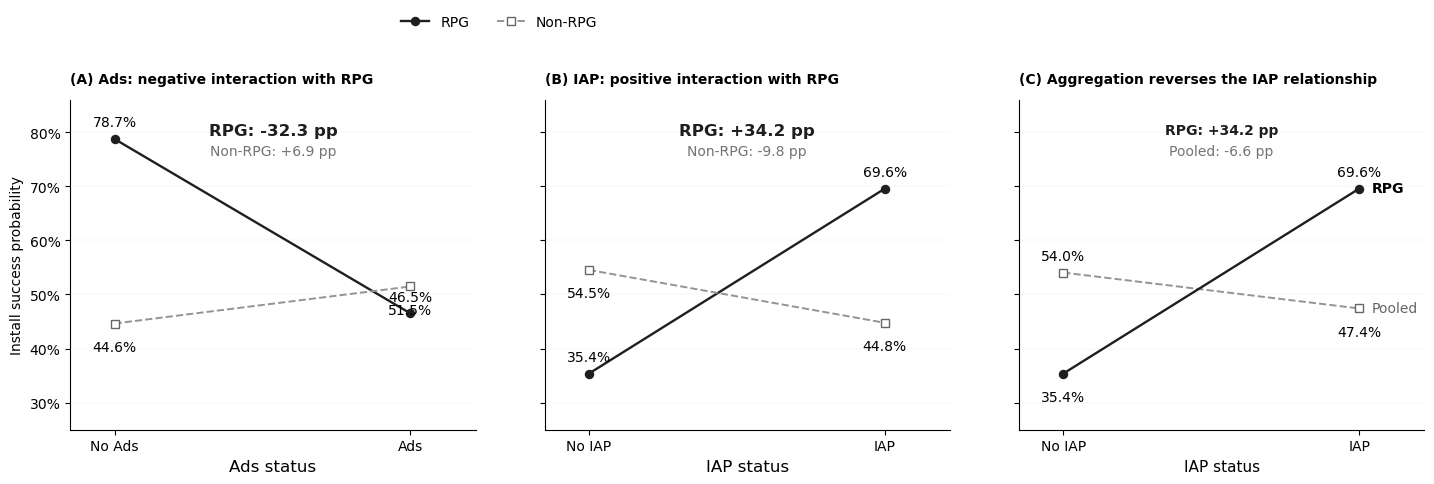

In [33]:
rpg_monetization_figure = plot_rpg_monetization_comparison(
    df=apps,
    country="US",
    outcome="install_success",
    filename="rpg_monetization_comparison"
)